In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import re
import warnings
warnings.filterwarnings('ignore')

In [181]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [182]:
df_mini = pd.read_csv('../data/clear_data/df_W40K.csv')
df_lore = pd.read_csv('../data/clear_data/lore_books.csv')
df_faction = pd.read_csv('../data/clear_data/faction_own.csv')
df_market = pd.read_csv('../data/clear_data/print3d_market.csv')

In [183]:
df_mini['price'] = pd.to_numeric(df_mini['price'], errors='coerce')
df_mini['cost'] = pd.to_numeric(df_mini['cost'], errors='coerce')

df_mini['year'] = pd.to_numeric(df_mini['year'], errors='coerce').astype('Int64')
df_lore['year'] = pd.to_numeric(df_lore['year'], errors='coerce').astype('Int64')
df_market['year'] = pd.to_numeric(df_market['year'], errors='coerce')

# Normalizar faction_clean
df_mini['faction_clean'] = df_mini['faction'].str.strip()
df_lore['faction_clean'] = df_lore['faction'].str.strip()
df_faction['faction_clean'] = df_faction['faction'].str.strip()


df_mini['material'] = df_mini['material'].astype(str).str.replace('?', '', regex=False)


In [184]:
print(f" Miniaturas: {df_mini.shape}")
print(f" Libros Lore: {df_lore.shape}")
print(f"  Stats Facciones: {df_faction.shape}")
print(f" Mercado 3D: {df_market.shape}")

 Miniaturas: (946, 11)
 Libros Lore: (234, 7)
  Stats Facciones: (28, 12)
 Mercado 3D: (10, 2)


### HIPÓTESIS 1:
#### ¿Existe relación entre la venta de Impresoras 3D y las figuras?

In [185]:
# 1.1 - Evolución temporal: miniaturas vs mercado 3D
mini_yearly = df_mini.groupby('year').agg({
    'mini': 'count',
    'price': ['mean', 'median'],
    'material': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'
}).reset_index()
mini_yearly.columns = ['year', 'mini_count', 'price_mean', 'price_median', 'material_mode']

# Merge con datos de mercado
market_analysis = pd.merge(
    df_market, 
    mini_yearly[['year', 'mini_count', 'price_mean']], 
    on='year', 
    how='left'
)

In [186]:
# 1.2 - Correlación
correlation = market_analysis[['market_size_eur_m', 'mini_count', 'price_mean']].corr()

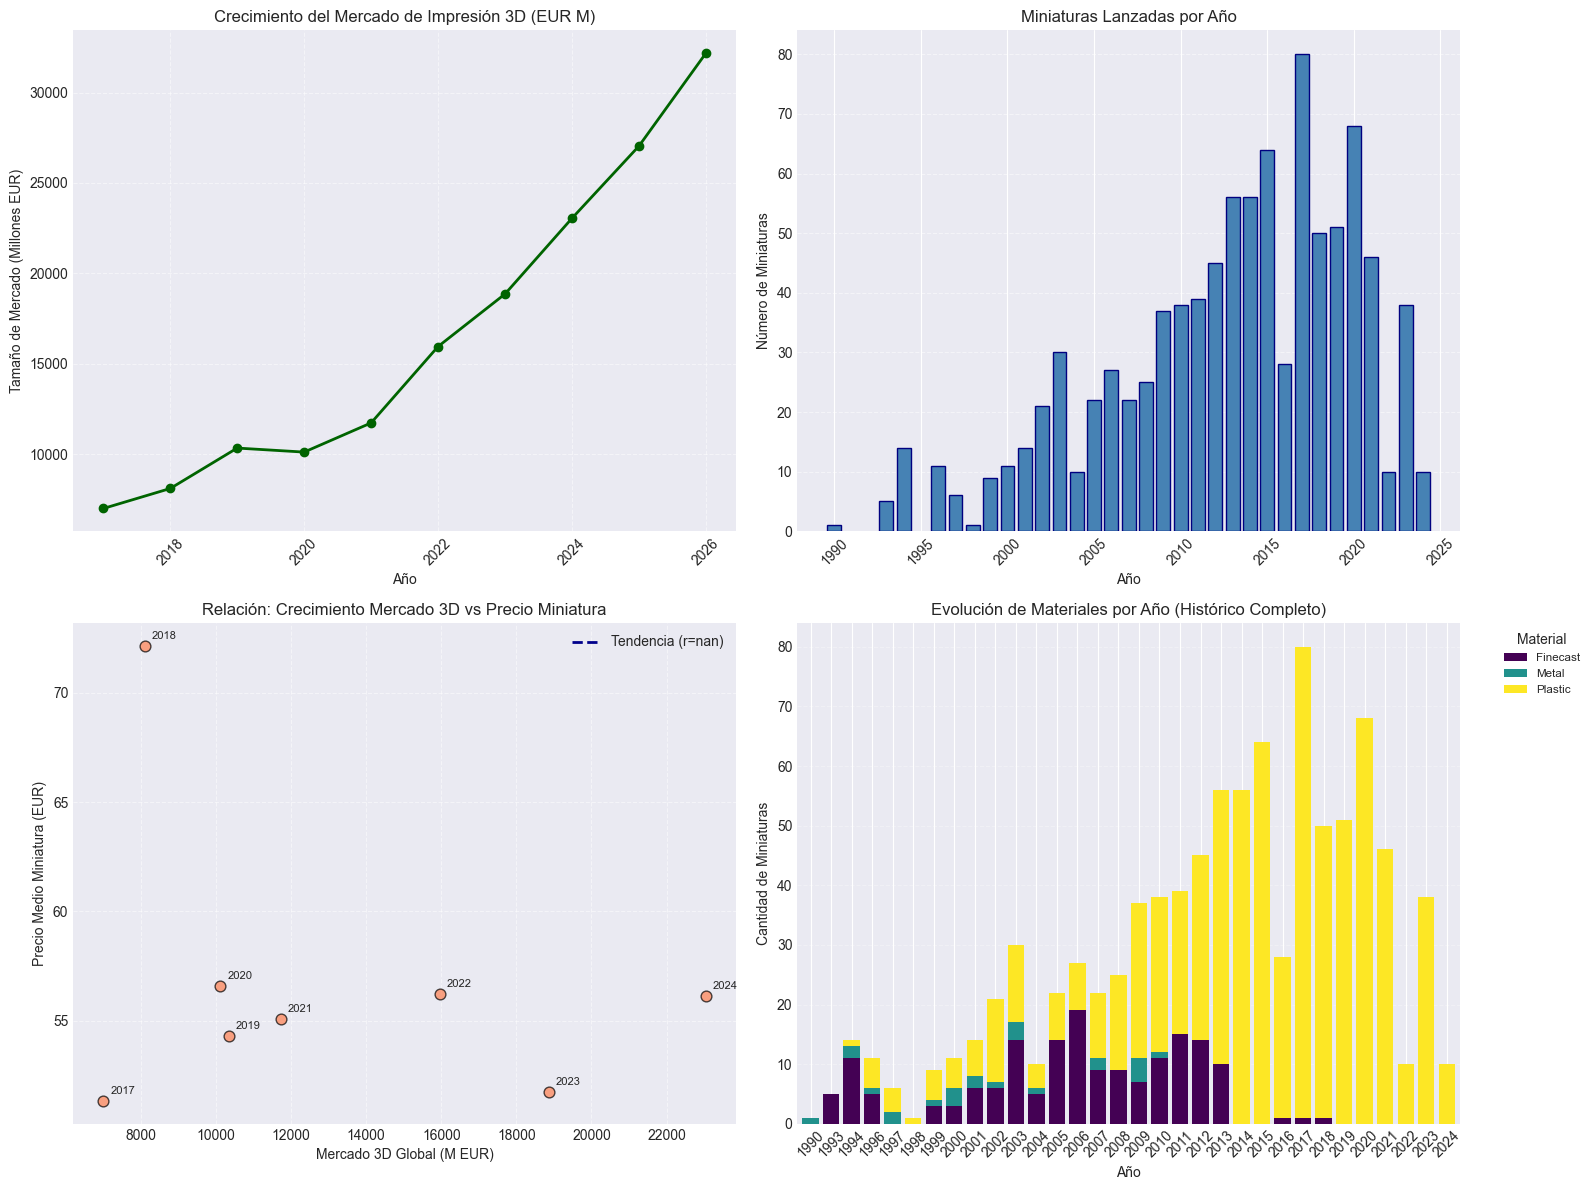

In [187]:
# 1.3 - Visualización
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Gráfico 1: Mercado 3D over time ---
axes[0, 0].plot(df_market['year'], df_market['market_size_eur_m'], marker='o', linewidth=2, color='darkgreen')
axes[0, 0].set_title('Crecimiento del Mercado de Impresión 3D (EUR M)')
axes[0, 0].set_xlabel('Año')
axes[0, 0].set_ylabel('Tamaño de Mercado (Millones EUR)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 2: Miniaturas lanzadas por año ---
axes[0, 1].bar(mini_yearly['year'], mini_yearly['mini_count'], color='steelblue', edgecolor='navy')
axes[0, 1].set_title('Miniaturas Lanzadas por Año')
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Miniaturas')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.5)

# --- Gráfico 3: Precio medio vs mercado ---
x = market_analysis['market_size_eur_m']
y = market_analysis['price_mean']

# 1. Dibujar los puntos
axes[1, 0].scatter(x, y, alpha=0.7, s=60, c='coral', edgecolors='black', zorder=5)

# 2. Calcular y dibujar la línea de tendencia (Regresión Lineal)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
line_x = np.linspace(x.min(), x.max(), 100)
line_y = slope * line_x + intercept
axes[1, 0].plot(line_x, line_y, color='darkblue', linestyle='--', linewidth=2, label=f'Tendencia (r={r_value:.2f})')

# 3. Etiquetar cada punto con el Año (para poder identificarlos)
for i, txt in enumerate(market_analysis['year']):
    axes[1, 0].annotate(txt, (x.iloc[i], y.iloc[i]), textcoords="offset points", xytext=(5,5), fontsize=8)

axes[1, 0].set_title('Relación: Crecimiento Mercado 3D vs Precio Miniatura')
axes[1, 0].set_xlabel('Mercado 3D Global (M EUR)')
axes[1, 0].set_ylabel('Precio Medio Miniatura (EUR)')
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- Gráfico 4: Evolución de Materiares (BARRAS APILADAS - TODOS LOS AÑOS) ---
# 1. Agrupamos por año y material
material_evolution = df_mini.groupby(['year', 'material']).size().unstack(fill_value=0)

# 2. Ploteamos como barras apiladas
# kind='bar' y stacked=True crea el efecto de torre por año
material_evolution.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='viridis', width=0.8)

axes[1, 1].set_title('Evolución de Materiales por Año (Histórico Completo)')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Cantidad de Miniaturas')

# Ajustes para legibilidad
axes[1, 1].tick_params(axis='x', rotation=45) # Rota los años para que se lean
axes[1, 1].legend(title='Material', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.3) # Solo grid horizontal para no saturar

# Ajuste final para que no se corten las etiquetas
plt.tight_layout()

# Guardar
plt.savefig('../img/hipotesis_1_market_analysis.png', dpi=300, bbox_inches='tight')

In [188]:
# 1.4 - Resultados estadísticos
print("\n RESULTADOS HIPÓTESIS 1:")
print(f"Correlación Mercado 3D ↔ Cantidad Miniaturas: {correlation.loc['market_size_eur_m', 'mini_count']:.3f}")
print(f"Correlación Mercado 3D ↔ Precio Medio: {correlation.loc['market_size_eur_m', 'price_mean']:.3f}")

# Test de correlación de Pearson
if market_analysis['market_size_eur_m'].notna().all() and market_analysis['mini_count'].notna().all():
    r, p_value = stats.pearsonr(
        market_analysis['market_size_eur_m'].dropna(), 
        market_analysis['mini_count'].dropna()
    )
    print(f" Pearson r={r:.3f}, p-value={p_value:.4f}")
    print(f" {'Correlación significativa' if p_value < 0.05 else 'Sin correlación significativa'}")


 RESULTADOS HIPÓTESIS 1:
Correlación Mercado 3D ↔ Cantidad Miniaturas: -0.834
Correlación Mercado 3D ↔ Precio Medio: -0.275


### HIPÓTESIS 2:
#### ¿Qué probabilidad hay de que tu facción favorita sea renovada?

In [189]:
# 2.1 - Frecuencia de lanzamientos por facción
faction_releases = df_mini.groupby('faction_clean').agg({
    'year': ['min', 'max', 'count', 'mean'],
    'edition': lambda x: x.nunique()
}).reset_index()
faction_releases.columns = ['faction', 'first_release', 'last_release', 'total_minis', 'avg_year', 'unique_editions']

In [190]:
# 2.2 - Calcular "probabilidad de renovación" 
# (basado en frecuencia histórica y tiempo desde último lanzamiento)
current_year = 2025
faction_releases['years_since_last'] = current_year - faction_releases['last_release']
faction_releases['release_rate'] = faction_releases['total_minis'] / (faction_releases['last_release'] - faction_releases['first_release'] + 1)

In [191]:
# Score de probabilidad (heurístico)
faction_releases['renewal_score'] = (
    faction_releases['release_rate'] * 0.4 +  # Frecuencia histórica
    (1 / (faction_releases['years_since_last'] + 1)) * 0.3 +  # Recencia
    faction_releases['unique_editions'] * 0.3  # Soporte de ediciones
)
faction_releases['reivals_score'] = faction_releases['renewal_score'] / faction_releases['renewal_score'].max() * 100

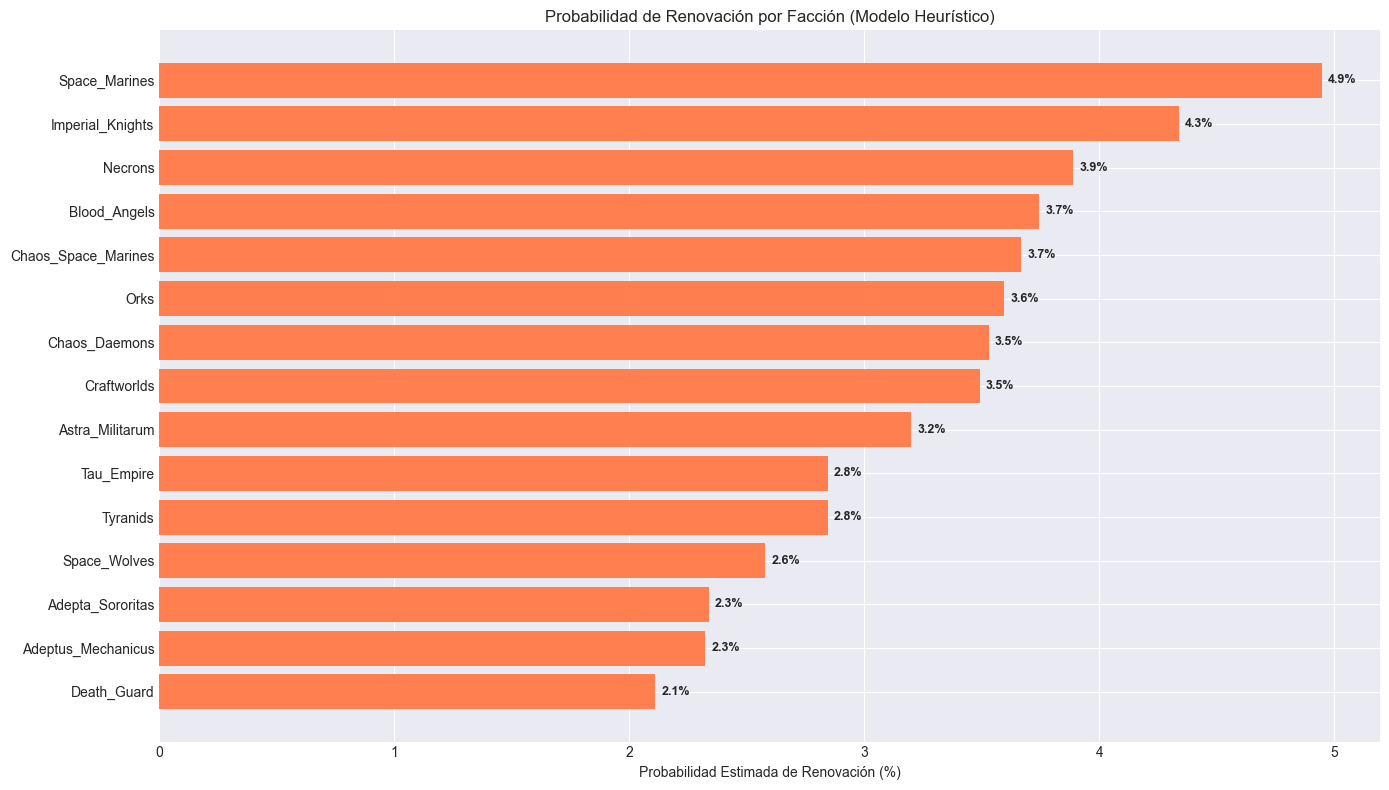

In [192]:
# 2.3 - Visualización
plt.figure(figsize=(14, 8))

# Seleccionar top 15
top_factions = faction_releases.nlargest(15, 'renewal_score')

bars = plt.barh(top_factions['faction'], top_factions['renewal_score'], color='coral')

# Invertir eje Y para que la #1 esté arriba
plt.gca().invert_yaxis()

# Títulos y etiquetas
plt.xlabel('Probabilidad Estimada de Renovación (%)')
plt.title('Probabilidad de Renovación por Facción (Modelo Heurístico)')

# Obtenemos el límite máximo actual del eje X para calcular la posición relativa
xmax = plt.xlim()[1] 

for bar, score in zip(bars, top_factions['renewal_score']):
    x_pos = bar.get_width() + (xmax * 0.005) 
    
    plt.text(x_pos, bar.get_y() + bar.get_height()/2, 
             f'{score:.1f}%', 
             va='center',
             ha='left',
             fontsize=9,
             fontweight='bold')

# Ajuste final para que no se corte nada
plt.tight_layout()

# Guardar
plt.savefig('../img/hipotesis_2_renewal_probability.png', dpi=300, bbox_inches='tight')

In [193]:
# 2.4 - Tabla de consulta rápida
print("\n RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:")
print(faction_releases[['faction', 'total_minis', 'years_since_last', 'release_rate', 'renewal_score']]
      .nlargest(10, 'renewal_score')
      .to_string(index=False))


 RESULTADOS HIPÓTESIS 2 - Top 10 Facciones con Mayor Probabilidad de Renovación:
            faction  total_minis  years_since_last  release_rate  renewal_score
      Space_Marines          152                 1          5.24           4.95
   Imperial_Knights           10                 7         10.00           4.34
            Necrons           77                 1          3.35           3.89
       Blood_Angels           50                 2          1.61           3.75
Chaos_Space_Marines           73                 2          2.92           3.67
               Orks           68                 1          2.62           3.60
      Chaos_Daemons           54                 2          2.57           3.53
        Craftworlds           59                 3          1.79           3.49
    Astra_Militarum           49                 2          1.75           3.20
         Tau_Empire           37                 2          1.61           2.84


In [194]:
# Función para consultar probabilidad de una facción específica
def get_renewal_probability(faction_name):
    """Consulta la probabilidad de renovación para una facción"""
    result = faction_releases[faction_releases['faction'].str.contains(faction_name, case=False, na=False)]
    if not result.empty:
        return result[['faction', 'renewal_score', 'years_since_last', 'total_minis']].iloc[0]
    return None

In [195]:
print(get_renewal_probability("Space_Marines"))

faction             Chaos_Space_Marines
renewal_score                      3.67
years_since_last                      2
total_minis                          73
Name: 7, dtype: object


### HIPÓTESIS 3:
#### ¿Existe una facción predilecta de la compañía? ¿Y una aborrecida?

In [196]:
# 3.1 - Métricas de "favoritismo" por facción
faction_support = df_mini.groupby('faction_clean').agg({
    'mini': 'count',
    'price': ['mean', 'sum'],
    'year': 'nunique',
    'edition': 'nunique'
}).reset_index()
faction_support.columns = ['faction', 'mini_count', 'price_avg', 'price_total', 'active_years', 'editions_supported']

In [197]:
# 3.2 - Merge con stats de juego (Owned, Win Rate)
faction_support = pd.merge(
    faction_support,
    df_faction[['faction', 'Owned', 'Primary', 'Win %', 'Real Win %']],
    on='faction',
    how='left'
)

In [198]:
# 3.3 - Calcular índice de "favoritismo"
# Combinación de: producción, inversión, soporte temporal y popularidad
faction_support['support_index'] = (
    faction_support['mini_count'] / faction_support['mini_count'].max() * 0.3 +
    faction_support['price_total'] / faction_support['price_total'].max() * 0.3 +
    faction_support['editions_supported'] / faction_support['editions_supported'].max() * 0.2 +
    faction_support['Owned'].fillna(0) / faction_support['Owned'].fillna(0).max() * 0.2
) * 100

In [199]:
faction_support['Win %'] = faction_support['Win %'].str.replace(',', '.', regex=False)

In [200]:
faction_support['Win %'] = pd.to_numeric(faction_support['Win %'], errors='coerce')

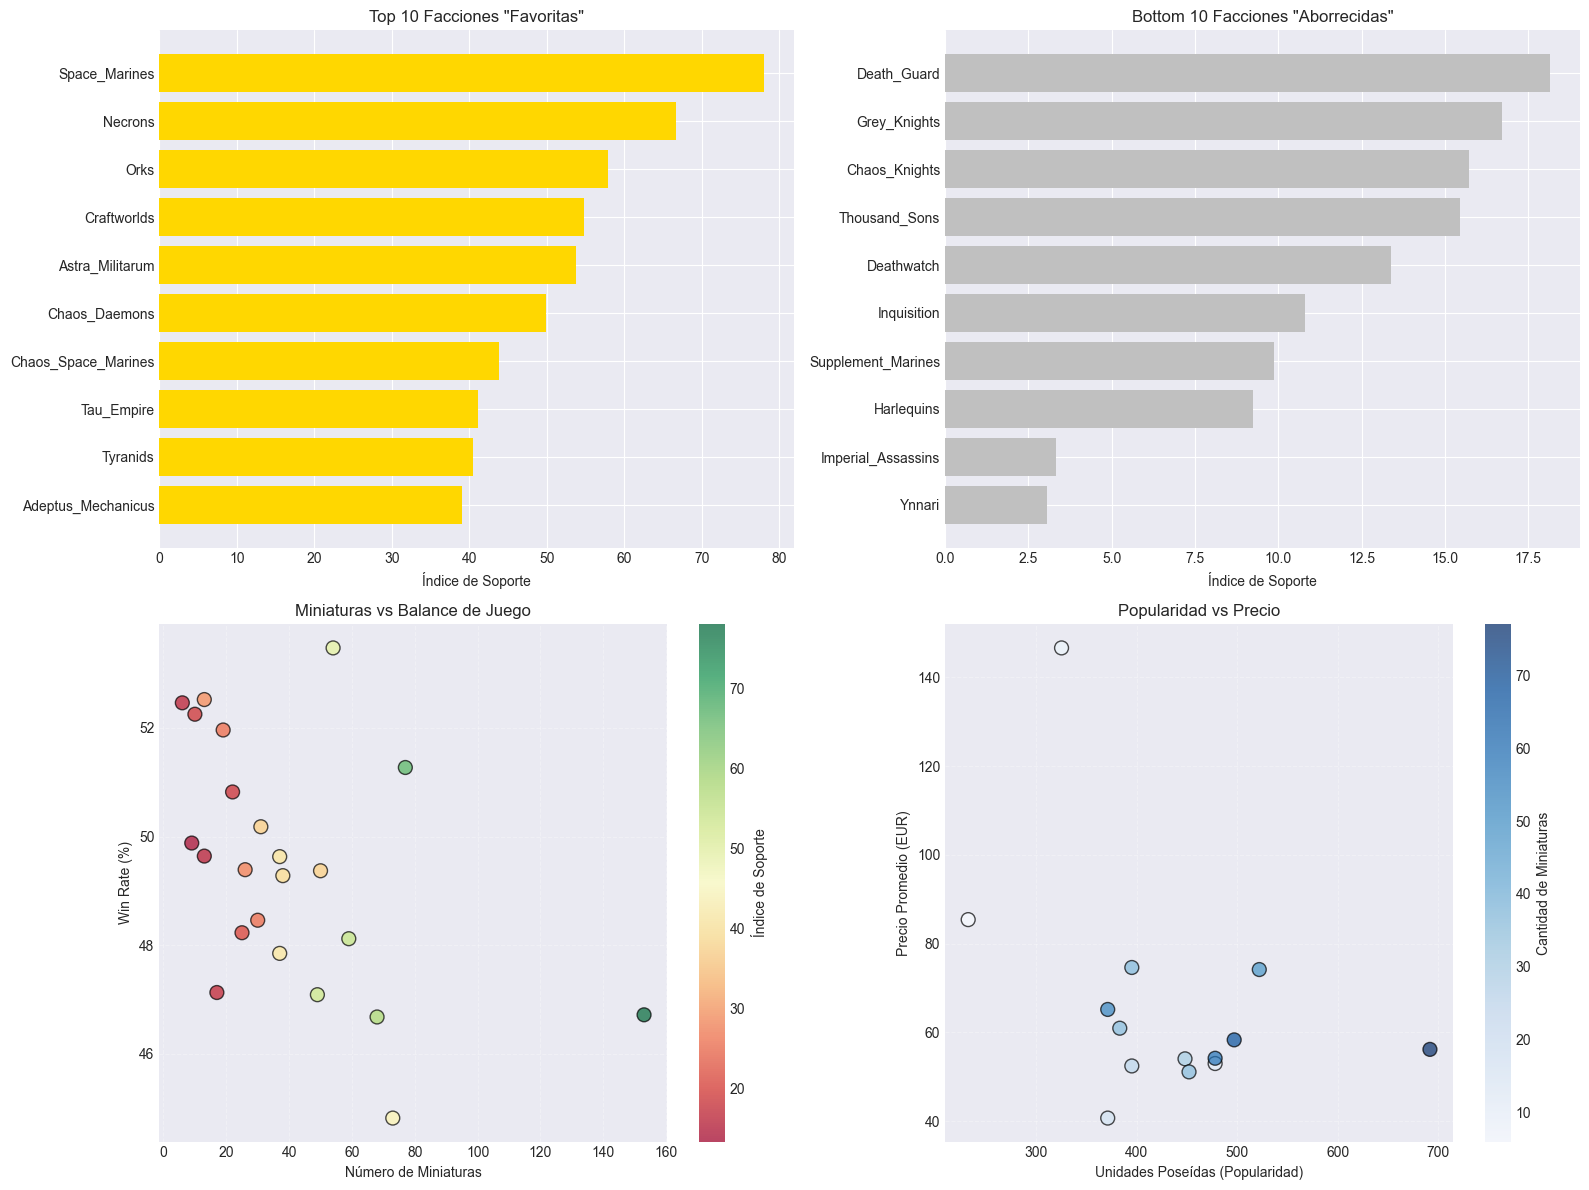

In [201]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Gráficos 1 y 2 (Barras Horizontales) ---
sorted_factions = faction_support.sort_values('support_index', ascending=False)

axes[0, 0].barh(sorted_factions['faction'].head(10), sorted_factions['support_index'].head(10), color='gold')
axes[0, 0].set_title('Top 10 Facciones "Favoritas"')
axes[0, 0].set_xlabel('Índice de Soporte')
axes[0, 0].invert_yaxis()

axes[0, 1].barh(sorted_factions['faction'].tail(10), sorted_factions['support_index'].tail(10), color='silver')
axes[0, 1].set_title('Bottom 10 Facciones "Aborrecidas"')
axes[0, 1].set_xlabel('Índice de Soporte')
axes[0, 1].invert_yaxis()

# --- Gráfico 3: Miniaturas vs Win Rate (FILTRANDO NaN) ---
mask_win = faction_support['Win %'].notna()

# 2. Aplicamos la máscara a todas las variables involucradas en este gráfico
x3 = faction_support.loc[mask_win, 'mini_count']
y3 = faction_support.loc[mask_win, 'Win %']
c3 = faction_support.loc[mask_win, 'support_index']

scatter = axes[1, 0].scatter(x3, y3, c=c3, cmap='RdYlGn', s=100, alpha=0.7, edgecolors='black')
axes[1, 0].set_xlabel('Número de Miniaturas')
axes[1, 0].set_ylabel('Win Rate (%)')
axes[1, 0].set_title('Miniaturas vs Balance de Juego')
plt.colorbar(scatter, ax=axes[1, 0], label='Índice de Soporte')
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 4: Precio vs Popularidad (FILTRANDO NaN) ---
# 1. Máscara para Owned y price_avg
mask_pop = faction_support['Owned'].notna() & faction_support['price_avg'].notna()

# 2. Aplicamos la máscara
x4 = faction_support.loc[mask_pop, 'Owned']
y4 = faction_support.loc[mask_pop, 'price_avg']
c4 = faction_support.loc[mask_pop, 'mini_count']

scatter2 = axes[1, 1].scatter(x4, y4, c=c4, cmap='Blues', s=100, alpha=0.7, edgecolors='black')
axes[1, 1].set_xlabel('Unidades Poseídas (Popularidad)')
axes[1, 1].set_ylabel('Precio Promedio (EUR)')
axes[1, 1].set_title('Popularidad vs Precio')
plt.colorbar(scatter2, ax=axes[1, 1], label='Cantidad de Miniaturas')
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/hipotesis_3_faction_support.png', dpi=300, bbox_inches='tight')
plt.show()

In [202]:
# 3.5 - Resultados
print("\n RESULTADOS HIPÓTESIS 3:")
print("\n TOP 5 Facciones con Mayor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].head().to_string(index=False))

print("\n BOTTOM 5 Facciones con Menor Soporte:")
print(sorted_factions[['faction', 'mini_count', 'price_avg', 'support_index']].tail().to_string(index=False))

# Test estadístico: ¿Hay diferencia significativa en win rate entre top/bottom?
top_factions = sorted_factions.nlargest(5, 'support_index')['Win %'].dropna()
bottom_factions = sorted_factions.nsmallest(5, 'support_index')['Win %'].dropna()

if len(top_factions) > 1 and len(bottom_factions) > 1:
    t_stat, p_val = stats.ttest_ind(top_factions, bottom_factions)
    print(f"\n Test T: Win Rate Top vs Bottom")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
    print(f"   {' Diferencia significativa' if p_val < 0.05 else '❌ Sin diferencia significativa'}")


 RESULTADOS HIPÓTESIS 3:

 TOP 5 Facciones con Mayor Soporte:
        faction  mini_count  price_avg  support_index
  Space_Marines         153      54.65          78.00
        Necrons          77      56.16          66.61
           Orks          68      58.31          57.92
    Craftworlds          59      54.16          54.85
Astra_Militarum          49      74.15          53.73

 BOTTOM 5 Facciones con Menor Soporte:
           faction  mini_count  price_avg  support_index
       Inquisition           8      42.66          10.79
Supplement_Marines           5      49.13           9.86
        Harlequins          10      35.93           9.25
Imperial_Assassins           4      37.38           3.32
            Ynnari           3      42.47           3.05


### HIPÓTESIS 4:
#### ¿Se pueden predecir acontecimientos del Lore en base a las colecciones de figuras?

In [203]:
# 4.1 - Preparar datos: libros por facción y año
# Limpiar Lore
df_lore_clean = df_lore.copy()
# Asumimos que 'faction' es la columna clave. Eliminamos ceros y nulos.
df_lore_clean = df_lore_clean[
    df_lore_clean['faction'].notna() & 
    (df_lore_clean['faction'] != 0) & 
    (df_lore_clean['faction'] != '0')
]

# Limpiar Miniaturas
df_mini_clean = df_mini.copy()
# Asumimos que 'faction_clean' es la columna clave.
df_mini_clean = df_mini_clean[
    df_mini_clean['faction_clean'].notna() & 
    (df_mini_clean['faction_clean'] != 0) & 
    (df_mini_clean['faction_clean'] != '0')
]

In [204]:
# 4.2 - Miniaturas por facción y año

# Agrupar Lore
lore_by_year = df_lore_clean.groupby(['faction', 'year']).size().reset_index(name='book_count')

# Agrupar Miniaturas
minis_by_year = df_mini_clean.groupby(['faction_clean', 'year']).size().reset_index(name='mini_count')

In [205]:
# 4.3 - Merge y análisis de correlación temporal
# Renombramos las columnas de facción para que sean idénticas antes del merge
lore_by_year.rename(columns={'faction': 'faction_std'}, inplace=True)
minis_by_year.rename(columns={'faction_clean': 'faction_std'}, inplace=True)

# Hacemos el merge outer para tener todos los años donde hubo ALGUNA actividad
lore_mini_merge = pd.merge(
    lore_by_year,
    minis_by_year,
    on=['faction_std', 'year'],
    how='outer'
).fillna(0)

In [206]:
# 4.4 - Correlación Lore ↔ Miniaturas DENTRO de cada facción (CORREGIDO)
faction_correlations = []

# Iteramos sobre las facciones que existen en el merge limpio
for faction in lore_mini_merge['faction_std'].unique():
    # Extraer datos de esta facción
    subset = lore_mini_merge[lore_mini_merge['faction_std'] == faction]
    
    # Necesitamos al menos 3 puntos de datos para que la correlación tenga sentido estadístico
    # Y que haya varianza (que no sean todos ceros o todos iguales)
    if len(subset) >= 3 and subset['book_count'].std() > 0 and subset['mini_count'].std() > 0:
        r, p = stats.pearsonr(subset['book_count'], subset['mini_count'])
        faction_correlations.append({
            'faction': faction,
            'correlation': r,
            'p_value': p,
            'n_years': len(subset),
            'significant': p < 0.05
        })
    else:
        # Opcional: Registrar facciones con datos insuficientes para saber cuáles faltan
        faction_correlations.append({
            'faction': faction,
            'correlation': np.nan,
            'p_value': np.nan,
            'n_years': len(subset),
            'significant': False
        })

corr_df = pd.DataFrame(faction_correlations)

✅ Correlaciones INTRA-facción (Lore ↔ Miniaturas):
            faction  correlation  p_value  significant
 Imperial_Assassins        -1.00     0.00         True
           Drukhari        -0.79     0.06        False
         Harlequins        -0.74     0.01         True
 Supplement_Marines        -0.69     0.13        False
         Deathwatch        -0.64     0.12        False
        Inquisition        -0.60     0.04         True
      Chaos_Knights        -0.55     0.08        False
      Thousand_Sons        -0.52     0.16        False
   Genestealer_Cult         0.45     0.37        False
      Chaos_Daemons         0.45     0.09        False
       Grey_Knights        -0.42     0.26        False
            Necrons        -0.34     0.18        False
           Tyranids        -0.34     0.37        False
        Craftworlds        -0.28     0.21        False
        Dark_Angels         0.27     0.46        False
        Death_Guard         0.26     0.57        False
       Space_W

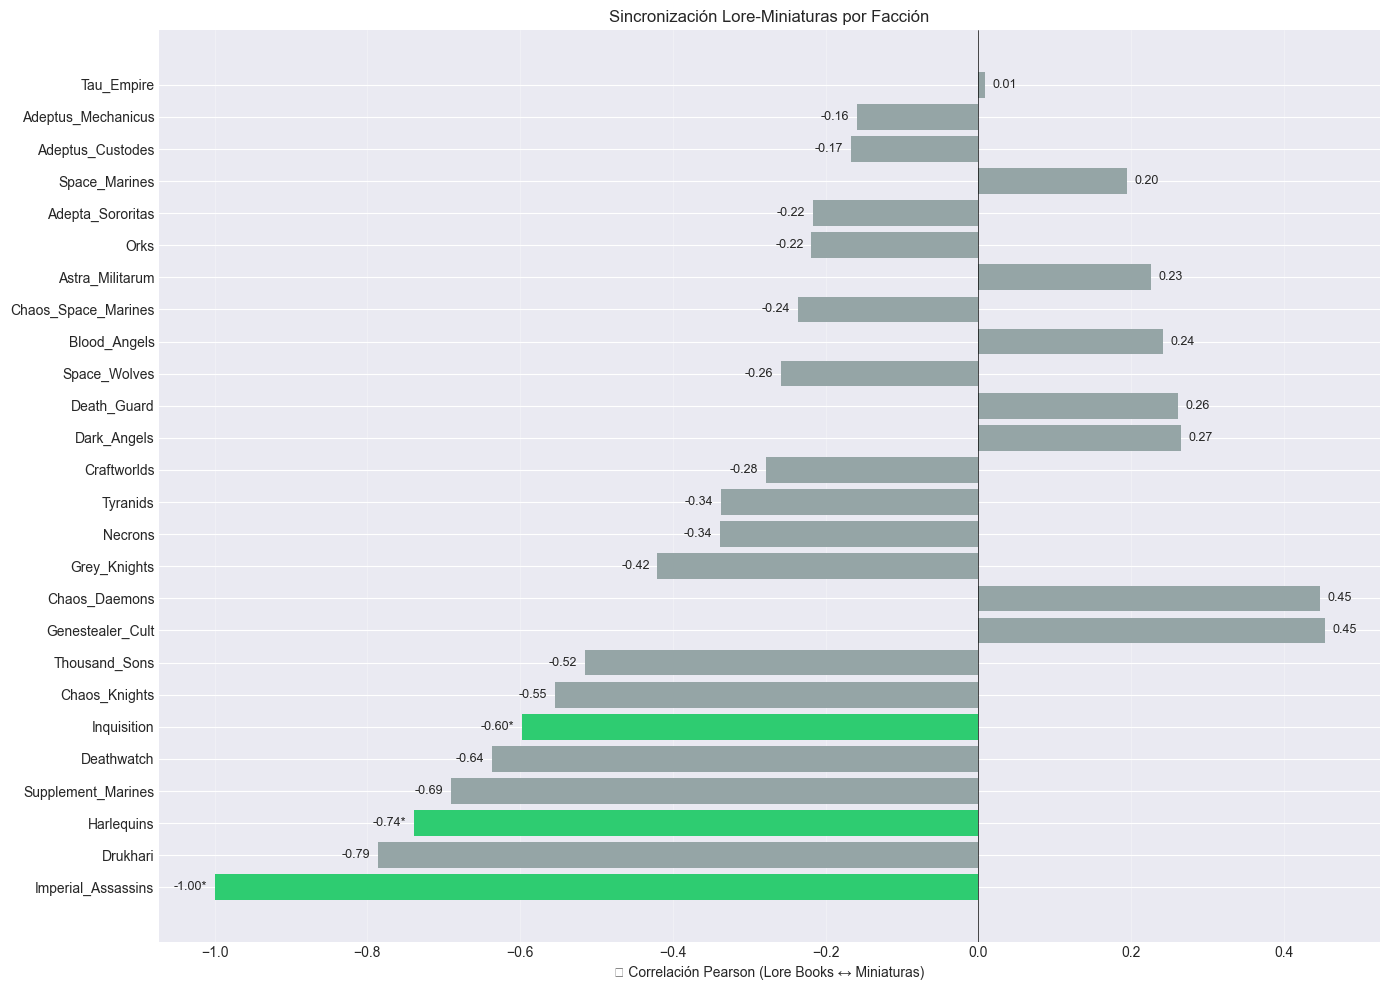

In [267]:
# 4.5 - Visualización:  Barras por facción
plt.figure(figsize=(14, 10))

# Ordenamos por correlación absoluta (las más fuertes arriba, sean positivas o negativas)
# dropna elimina las que no tuvieron suficientes datos
valid_corr = corr_df.dropna(subset=['correlation']).sort_values('correlation', key=abs, ascending=False)

if valid_corr.empty:
    print("⚠️ No hay correlaciones válidas para mostrar. Revisa los datos.")
else:
    # Colores: Verde si es significativo, Gris si no
    colors = ['#2ecc71' if row['significant'] else '#95a5a6' for _, row in valid_corr.iterrows()]
    
    bars = plt.barh(valid_corr['faction'], valid_corr['correlation'], color=colors)

    plt.xlabel('🔗 Correlación Pearson (Lore Books ↔ Miniaturas)')
    plt.title('Sincronización Lore-Miniaturas por Facción')
    plt.axvline(x=0, color='black', linewidth=0.5)
    plt.grid(axis='x', alpha=0.3)

    # Añadir etiquetas de valor
    for bar, row in zip(bars, valid_corr.itertuples()):
        val = row.correlation
        # Posición del texto: un poco a la derecha de la barra
        x_pos = bar.get_width() + (max(valid_corr['correlation'].abs()) * 0.01) 
        
        # Si la barra es negativa, ajustar el texto a la izquierda
        if val < 0:
            x_pos = bar.get_width() - (max(valid_corr['correlation'].abs()) * 0.01)
            ha = 'right'
        else:
            ha = 'left'

        plt.text(x_pos, bar.get_y() + bar.get_height()/2, 
                 f"{val:.2f}{'*' if row.significant else ''}", 
                 va='center', ha=ha, fontsize=9)

    plt.tight_layout()
    plt.savefig('../img/hipotesis_4_intra_faction_corr.png', dpi=300, bbox_inches='tight')
    
    print("✅ Correlaciones INTRA-facción (Lore ↔ Miniaturas):")
    print(valid_corr[['faction', 'correlation', 'p_value', 'significant']].to_string(index=False))

In [208]:
# 4.6 - Ejemplo detallado: Space Marines
def analyze_lore_mini_sync(faction_name):
    """Analiza sincronización entre lanzamientos de lore y miniaturas"""
    faction_lore = df_lore[df_lore['faction'] == faction_name].groupby('year').size()
    faction_minis = df_mini[df_mini['faction_clean'] == faction_name].groupby('year').size()
    
    # Crear dataframe combinado
    years = sorted(set(faction_lore.index) | set(faction_minis.index))
    sync_df = pd.DataFrame({
        'year': years,
        'books': [faction_lore.get(y, 0) for y in years],
        'minis': [faction_minis.get(y, 0) for y in years]
    })
    # Gráfico de sincronización
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    ax1.bar(sync_df['year'], sync_df['minis'], alpha=0.6, label='Miniaturas', color='steelblue')
    ax1.set_xlabel('Año')
    ax1.set_ylabel('Número de Miniaturas', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    ax2 = ax1.twinx()
    ax2.plot(sync_df['year'], sync_df['books'], marker='o', color='crimson', linewidth=2, label='Libros Lore')
    ax2.set_ylabel('Número de Libros', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    plt.title(f' Sincronización Lore ↔ Miniaturas: {faction_name}')
    plt.grid(axis='x', alpha=0.3)
    
    # Añadir líneas para eventos notables
    peaks = sync_df[(sync_df['books'] > sync_df['books'].quantile(0.75)) | 
                    (sync_df['minis'] > sync_df['minis'].quantile(0.75))]
    for _, row in peaks.iterrows():
        ax1.axvline(row['year'], color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return sync_df, fig

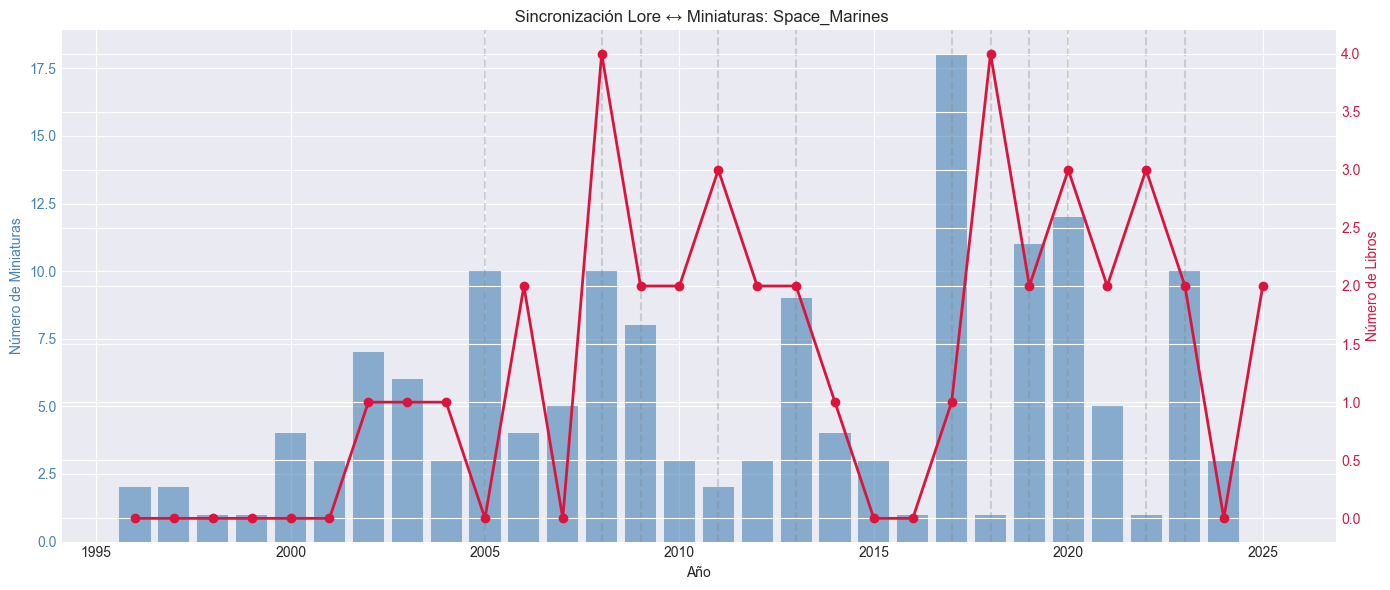

In [268]:
# Ejecutar para Space Marines
sm_sync, sm_fig = analyze_lore_mini_sync('Space_Marines')
sm_fig.savefig('../img/hipotesis_4_space_marines_sync.png', dpi=300, bbox_inches='tight')


In [269]:
# 4.7 - Resultados
print("\n RESULTADOS HIPÓTESIS 4:")
print("\n Correlación Lore ↔ Miniaturas por Facción (Top 10):")
print(corr_df.sort_values('correlation', key=abs, ascending=False)
      .head(10)[['faction', 'correlation', 'p_value', 'n_years']]
      .to_string(index=False))

print("\n Interpretación:")
print("   • r > 0.5: Fuerte correlación positiva (lore impulsa miniaturas)")
print("   • r < -0.5: Correlación negativa (posible estrategia inversa)")
print("   • p < 0.05: Correlación estadísticamente significativa")


 RESULTADOS HIPÓTESIS 4:

 Correlación Lore ↔ Miniaturas por Facción (Top 10):
           faction  correlation  p_value  n_years
Imperial_Assassins        -1.00     0.00        7
          Drukhari        -0.79     0.06        6
        Harlequins        -0.74     0.01       10
Supplement_Marines        -0.69     0.13        6
        Deathwatch        -0.64     0.12        7
       Inquisition        -0.60     0.04       12
     Chaos_Knights        -0.55     0.08       11
     Thousand_Sons        -0.52     0.16        9
  Genestealer_Cult         0.45     0.37        6
     Chaos_Daemons         0.45     0.09       15

 Interpretación:
   • r > 0.5: Fuerte correlación positiva (lore impulsa miniaturas)
   • r < -0.5: Correlación negativa (posible estrategia inversa)
   • p < 0.05: Correlación estadísticamente significativa


In [ ]:
# 4.5 - NUEVO: Correlación TEMPORAL ENTRE facciones

# Crear matriz año × facción para libros
lore_matrix = df_lore.pivot_table(
    index='year', 
    columns='faction', 
    values='titulo', 
    aggfunc='count', 
    fill_value=0
)

# Crear matriz año × facción para miniaturas  
mini_matrix = df_mini.pivot_table(
    index='year', 
    columns='faction_clean', 
    values='mini', 
    aggfunc='count', 
    fill_value=0
)

In [271]:
# Alinear índices (años comunes)
common_years = sorted(set(lore_matrix.index) & set(mini_matrix.index))
print(f"Años comunes: {len(common_years)}")

Años comunes: 26


In [ ]:
if len(common_years) == 0:
    print("❌ No hay años en común entre df_lore y df_mini")
    print(f"Rango lore: {lore_matrix.index.min()} - {lore_matrix.index.max()}")
    print(f"Rango mini: {mini_matrix.index.min()} - {mini_matrix.index.max()}")
else:
    lore_matrix = lore_matrix.loc[common_years]
    mini_matrix = mini_matrix.loc[common_years]
    
# Normalizar manejando la división por cero
lore_max = lore_matrix.max().replace(0, 1)
mini_max = mini_matrix.max().replace(0, 1)

lore_norm = lore_matrix.div(lore_max, axis=1)
mini_norm = mini_matrix.div(mini_max, axis=1)

# activity_matrix: promedio de actividad lore y mini (0 si no hay datos)
activity_matrix = (lore_norm + mini_norm) / 2

activity_matrix = activity_matrix.fillna(0)

print(f" Años analizados: {len(common_years)} ({min(common_years)}-{max(common_years)})")
print(f"  Facciones con datos: {activity_matrix.shape[1]}")
print(activity_matrix.head())

 Años analizados: 26 (1999-2024)
  Facciones con datos: 29
faction  Adepta_Sororitas  Adeptus_Custodes  Adeptus_Mechanicus  \
year                                                              
1999                 0.00              0.00                0.00   
2000                 0.00              0.00                0.00   
2001                 0.00              0.00                0.00   
2002                 0.00              0.00                0.00   
2003                 0.03              0.00                0.03   

faction  Astra_Militarum  Black_Templars  Blood_Angels  Chaos_Daemons  \
year                                                                    
1999                0.04            0.00          0.00           0.00   
2000                0.08            0.00          0.00           0.00   
2001                0.33            0.00          0.00           0.00   
2002                0.17            0.00          0.07           0.00   
2003                0.58         

In [273]:
# 4.6 - Calcular correlación de patrones temporales entre facciones
faction_pairs_corr = []
factions = activity_matrix.columns.tolist()

for i, fac1 in enumerate(factions):
    for fac2 in factions[i+1:]:
        # Solo calcular si ambas tienen varianza suficiente
        if activity_matrix[fac1].std() > 0 and activity_matrix[fac2].std() > 0:
            r, p = stats.pearsonr(activity_matrix[fac1], activity_matrix[fac2])
            faction_pairs_corr.append({
                'faction_1': fac1,
                'faction_2': fac2,
                'correlation': r,
                'p_value': p,
                'significant': p < 0.05
            })

pairs_df = pd.DataFrame(faction_pairs_corr)

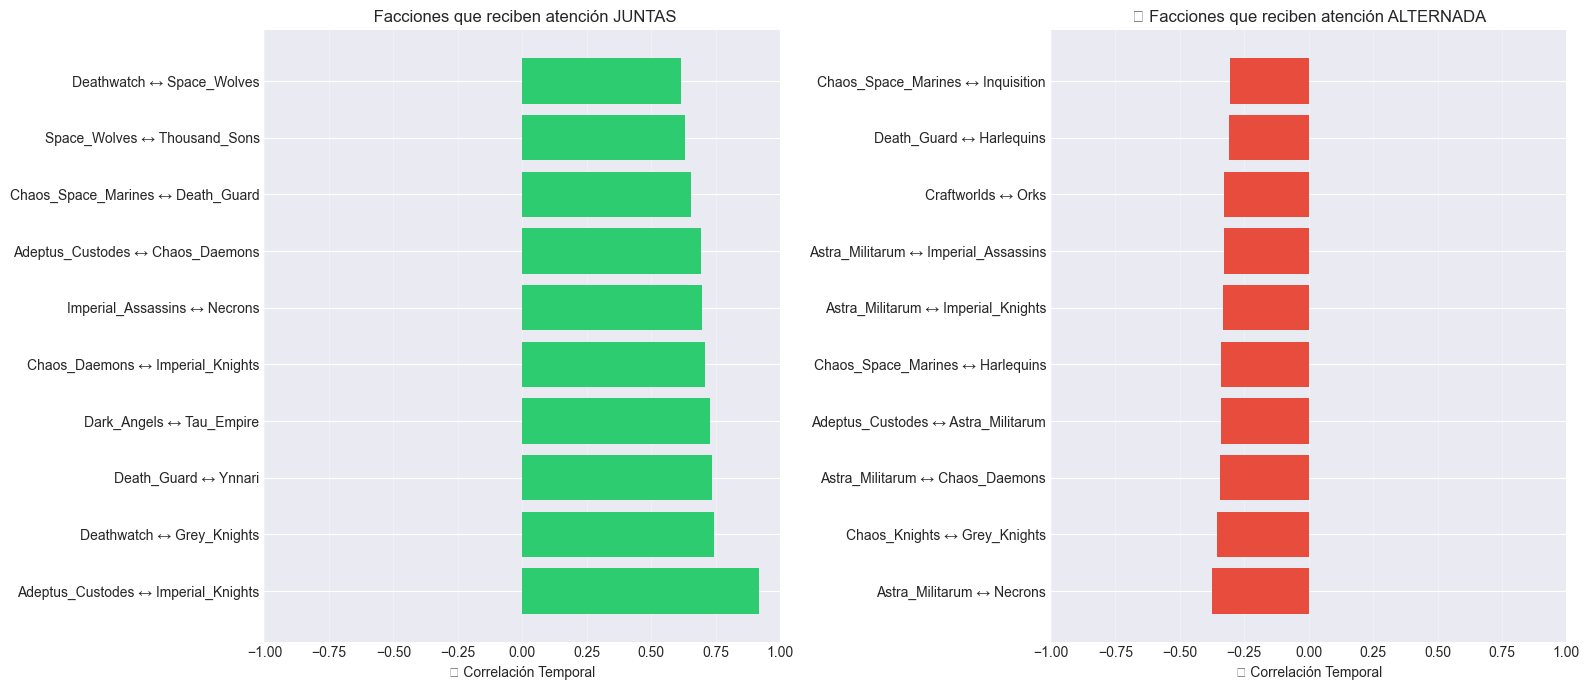

In [275]:
# 4.7 - Visualizar TOP correlaciones positivas y negativas
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 correlaciones POSITIVAS (se mueven juntas)
top_positive = pairs_df.nlargest(10, 'correlation')
axes[0].barh(top_positive['faction_1'] + ' ↔ ' + top_positive['faction_2'], 
             top_positive['correlation'], color='#2ecc71')
axes[0].set_xlabel('🔗 Correlación Temporal')
axes[0].set_title(' Facciones que reciben atención JUNTAS')
axes[0].set_xlim(-1, 1)
axes[0].grid(axis='x', alpha=0.3)

# Top 10 correlaciones NEGATIVAS (se mueven opuestas)
top_negative = pairs_df.nsmallest(10, 'correlation')
axes[1].barh(top_negative['faction_1'] + ' ↔ ' + top_negative['faction_2'], 
             top_negative['correlation'], color='#e74c3c')
axes[1].set_xlabel('🔗 Correlación Temporal')
axes[1].set_title('❌ Facciones que reciben atención ALTERNADA')
axes[1].set_xlim(-1, 1)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/hipotesis_4_inter_faction_corr.png', dpi=300, bbox_inches='tight')


In [276]:
print("Facciones en df_lore:", df_lore['faction'].nunique())
print("Facciones en df_mini:", df_mini['faction_clean'].nunique())

Facciones en df_lore: 30
Facciones en df_mini: 28


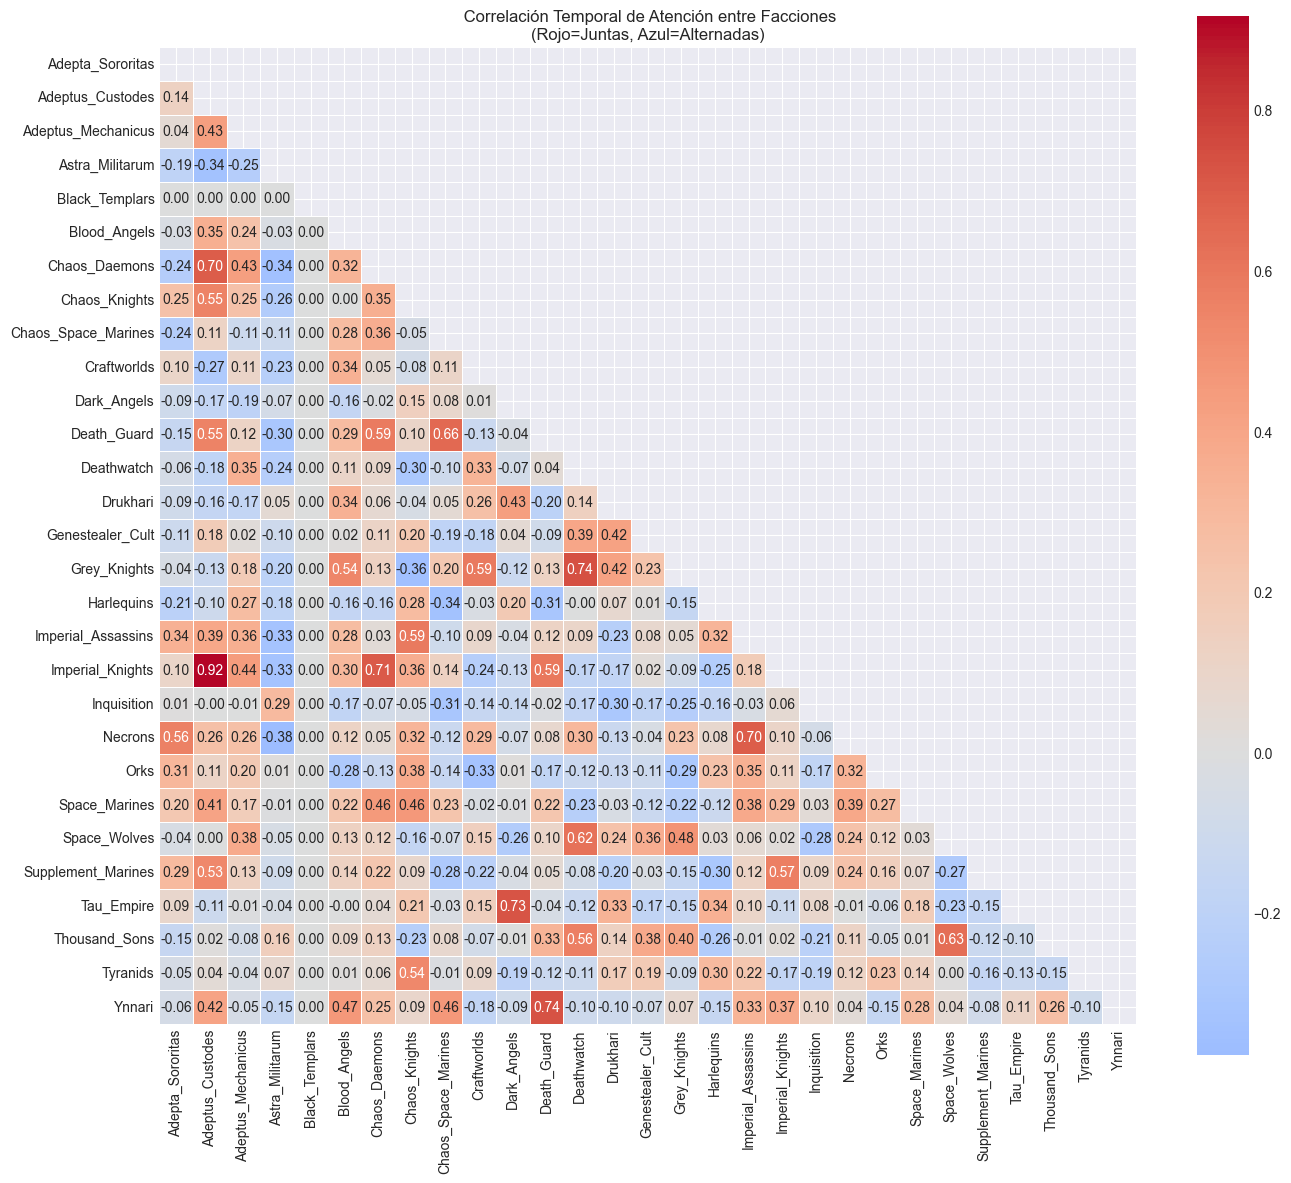

In [277]:

# 4.8 - Heatmap de correlaciones (matriz completa)
# Crear matriz simétrica para heatmap
corr_matrix = pd.DataFrame(np.eye(len(factions)), index=factions, columns=factions)

for _, row in pairs_df.iterrows():
    corr_matrix.loc[row['faction_1'], row['faction_2']] = row['correlation']
    corr_matrix.loc[row['faction_2'], row['faction_1']] = row['correlation']

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title(' Correlación Temporal de Atención entre Facciones\n(Rojo=Juntas, Azul=Alternadas)')
plt.tight_layout()
plt.savefig('../img/hipotesis_4_correlation_matrix.png', dpi=300, bbox_inches='tight')


###  HIPÓTESIS 5:
#### ¿Está balanceado el juego? ¿Existe un meta?

In [278]:
# 5.1 - Preparar datos de balance
balance_df = df_faction.copy()

# Limpiar y convertir columnas numéricas
for col in ['Win %', 'Real Win %', 'VP', 'Opp VP', 'Owned', 'Primary']:
    balance_df[col] = pd.to_numeric(balance_df[col].astype(str).str.replace(',', '.'), errors='coerce')

In [280]:
# 5.2 - Calcular métricas de balance
balance_df['vp_diff'] = balance_df['VP'] - balance_df['Opp VP']  # Diferencial de puntos
balance_df['popularity_ratio'] = balance_df['Owned'] / balance_df['Owned'].sum()  # Popularidad relativa
balance_df['performance_index'] = (
    balance_df['Real Win %'] * 0.6 +
    balance_df['vp_diff'] * 0.2 +
    (1 - balance_df['popularity_ratio']) * 20 * 0.2
)

In [296]:
# 5.3 - Clasificar facciones por estado de balance
balance_df['balance_status'] = pd.qcut(
    balance_df['performance_index'], 
    q=3, 
    labels=['Underpowered', 'Balanced', 'Overpowered'],
    duplicates='drop'
)

# Verificar que ahora sí hay variedad
print("Distribución corregida:")
print(balance_df['balance_status'].value_counts())

Distribución corregida:
balance_status
Underpowered    5
Overpowered     5
Balanced        4
Name: count, dtype: int64


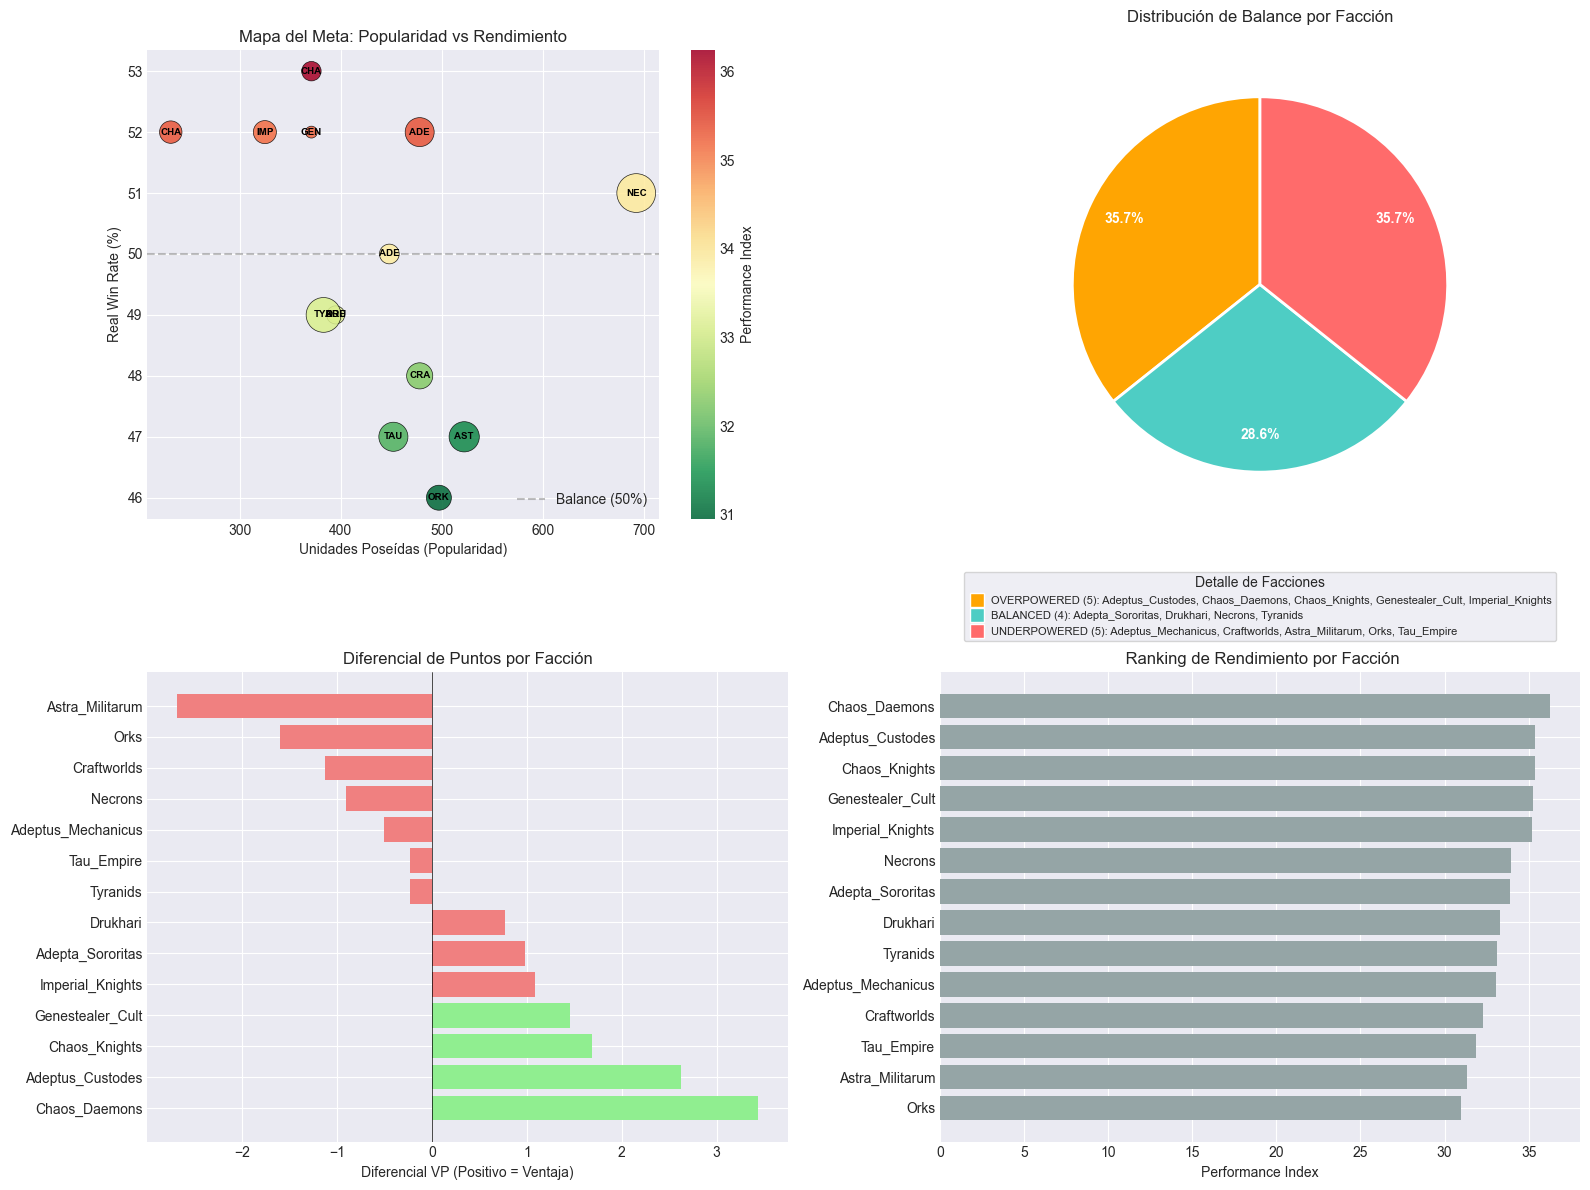

In [306]:
# 5.4 - Visualización del meta actual
fig, axes = plt.subplots(2, 2, figsize=(16, 12), squeeze=False)


# --- Gráfico 1: Mapa del Meta ---

if 'abbr' not in balance_df.columns:
    # Toma las primeras 3 letras y quita espacios/guiones bajos
    balance_df['abbr'] = balance_df['faction_clean'].str.replace('_', ' ').str[:3].str.upper()

# --- Gráfico 1: Mapa del Meta con Etiquetas ---

# 1. Calcular tamaños exagerados
sizes = (balance_df['Games'] / 500) ** 1.5 
sizes = sizes.clip(lower=15, upper=1500)

scatter = axes[0, 0].scatter(
    balance_df['Owned'].fillna(0),
    balance_df['Real Win %'],
    c=balance_df['performance_index'],
    cmap='RdYlGn_r', 
    s=sizes,          
    alpha=0.85, 
    edgecolors='black',
    linewidth=0.5,
    zorder=5
)

axes[0, 0].set_xlabel('Unidades Poseídas (Popularidad)')
axes[0, 0].set_ylabel('Real Win Rate (%)')
axes[0, 0].set_title('Mapa del Meta: Popularidad vs Rendimiento')
axes[0, 0].axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Balance (50%)')
axes[0, 0].legend(loc='lower right')
plt.colorbar(scatter, ax=axes[0, 0], label='Performance Index')

# 2. Añadir las SIGLAS sobre cada punto
mask_labels = balance_df['Games'] > 50 

for i, row in balance_df[mask_labels].iterrows():
    axes[0, 0].text(
        row['Owned'], 
        row['Real Win %'], 
        row['abbr'], 
        ha='center',
        va='center',
        fontsize=7,
        fontweight='bold', 
        color='black',
        zorder=6
    )

# --- Gráfico 2: Distribución de Balance ---

# 1. Preparación de datos y colores
balance_df['balance_status'] = balance_df['balance_status'].astype(str).str.strip()
status_order = ['Overpowered', 'Balanced', 'Underpowered']
color_map_pie = {
    'Overpowered': '#ffa502',    # Naranja
    'Balanced': '#4ecdc4',       # Turquesa
    'Underpowered': '#ff6b6b'    # Rojo
}

# Contar y reordenar para que coincida con nuestro orden lógico
counts = balance_df['balance_status'].value_counts().reindex(status_order).dropna()
colors_pie = [color_map_pie[s] for s in counts.index]

# 2. Dibujar la Tarta (Sin etiquetas internas para mayor limpieza)
wedges, texts, autotexts = axes[0, 1].pie(
    counts, 
    labels=None, 
    autopct='%1.1f%%', 
    colors=colors_pie,
    startangle=90,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # Bordes blancos para separar trozos
)

# Estilo de los porcentajes dentro de la tarta
plt.setp(autotexts, size=10, weight="bold", color="white")
axes[0, 1].set_title('Distribución de Balance por Facción', pad=20) # pad da espacio arriba

# 3. Crear Leyenda Detallada Abajo
legend_elements = []
for status in status_order:
    if status in counts.index:
        factions_list = balance_df[balance_df['balance_status'] == status]['faction_clean'].tolist()
        # Formateamos la lista: "SM, Eldar, Necrons"
        faction_str = ", ".join(factions_list)
        
        # Creamos el texto de la leyenda
        label_text = f"{status.upper()} ({len(factions_list)}): {faction_str}"
        
        legend_elements.append(
            plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=color_map_pie[status], 
                       markersize=10, label=label_text, linestyle='None')
        )

# 4. Posicionar la leyenda DEBAJO del gráfico
axes[0, 1].legend(
    handles=legend_elements, 
    loc="upper center",      # Anclaje superior del bloque de leyenda
    bbox_to_anchor=(0.5, -0.1), # Lo mueve hacia abajo (coordenadas negativas en Y)
    ncol=1,                  # 1 columna (lista vertical). Usa 3 si quieres horizontal.
    frameon=True,            # Marco alrededor de la leyenda
    fontsize=8,
    title="Detalle de Facciones",
    handlelength=1.5,
    handletextpad=0.5
)

# Ajuste final para que no se corte la leyenda de abajo
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Deja un 10% de espacio extra abajo


# --- Gráfico 3: Diferencial de Puntos por Facción ---

# VP Differential por facción
sorted_vp = balance_df.sort_values('vp_diff', ascending=False)
axes[1, 0].barh(sorted_vp['faction_clean'].head(10), sorted_vp['vp_diff'].head(10), color='lightgreen')
axes[1, 0].barh(sorted_vp['faction_clean'].tail(10), sorted_vp['vp_diff'].tail(10), color='lightcoral')
axes[1, 0].axvline(x=0, color='black', linewidth=0.5)
axes[1, 0].set_xlabel('Diferencial VP (Positivo = Ventaja)')
axes[1, 0].set_title('Diferencial de Puntos por Facción')

sorted_balance = balance_df.sort_values('performance_index', ascending=False)
color_map = {
    'Underpowered ': '#ff6b6b',
    'Balanced ': '#4ecdc4', 
    'Overpowered ': '#ffa502'
}

# Usar lista por comprensión para evitar el problema de Categorical
status_values = sorted_balance['balance_status'].head(15)
colors = [color_map.get(s, '#95a5a6') for s in status_values]

axes[1, 1].barh(sorted_balance['faction_clean'].head(15), 
                sorted_balance['performance_index'].head(15),
                color=colors)
axes[1, 1].set_xlabel('Performance Index')
axes[1, 1].set_title(' Ranking de Rendimiento por Facción')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.savefig('../img/hipotesis_5_game_balance.png', dpi=300, bbox_inches='tight')


In [307]:
# 5.5 - Análisis estadístico de balance
print("\n RESULTADOS HIPÓTESIS 5 - Balance del Juego:")
print(f"\n Estadísticas de Win Rate:")
print(f"   Media: {balance_df['Real Win %'].mean():.2f}%")
print(f"   Desviación: {balance_df['Real Win %'].std():.2f}%")
print(f"   Rango: {balance_df['Real Win %'].min():.2f}% - {balance_df['Real Win %'].max():.2f}%")

print(f"\n Distribución de Balance:")
for status in balance_df['balance_status'].unique():
    count = balance_df[balance_df['balance_status'] == status].shape[0]
    factions = balance_df[balance_df['balance_status'] == status]['faction_clean'].tolist()
    print(f"   {status}: {count} facciones - {', '.join(factions[:3])}{'...' if len(factions)>3 else ''}")


 RESULTADOS HIPÓTESIS 5 - Balance del Juego:

 Estadísticas de Win Rate:
   Media: 49.79%
   Desviación: 2.26%
   Rango: 46.00% - 53.00%

 Distribución de Balance:
   Balanced: 4 facciones - Adepta_Sororitas, Drukhari, Necrons...
   Overpowered: 5 facciones - Adeptus_Custodes, Chaos_Daemons, Chaos_Knights...
   Underpowered: 5 facciones - Adeptus_Mechanicus, Craftworlds, Astra_Militarum...


In [308]:
win_rates = balance_df['Real Win %'].dropna()
stat, p_normal = stats.normaltest(win_rates)
print(f"\n Test de Normalidad (Win Rate):")
print(f"   p-value: {p_normal:.4f} - {' Distribución normal' if p_normal > 0.05 else '❌ No normal'}")


 Test de Normalidad (Win Rate):
   p-value: 0.3223 -  Distribución normal


### HIPÓTESIS 6:
#### ¿Existe relación entre el poder de una figura y su precio? ¿Se puede predecir?

In [309]:
# 6.1 - Preparar datos: usar 'cost' como proxy de poder
power_price_df = df_mini[['mini', 'faction_clean', 'cost', 'price', 'year', 'material']].dropna(subset=['cost', 'price'])

In [310]:
# 6.2 - Análisis de correlación
correlation_power_price = power_price_df['cost'].corr(power_price_df['price'])
print(f"🔗 Correlación Poder (cost) ↔ Precio: {correlation_power_price:.3f}")

🔗 Correlación Poder (cost) ↔ Precio: 0.742


In [311]:
# 6.3 - Modelo de regresión lineal simple
X = power_price_df[['cost']]
y = power_price_df['price']

model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)

print(f" Modelo: Precio = {model.intercept_:.2f} + {model.coef_[0]:.2f} * Cost")
print(f" R² del modelo: {r_squared:.3f}")

 Modelo: Precio = 27.82 + 0.24 * Cost
 R² del modelo: 0.551


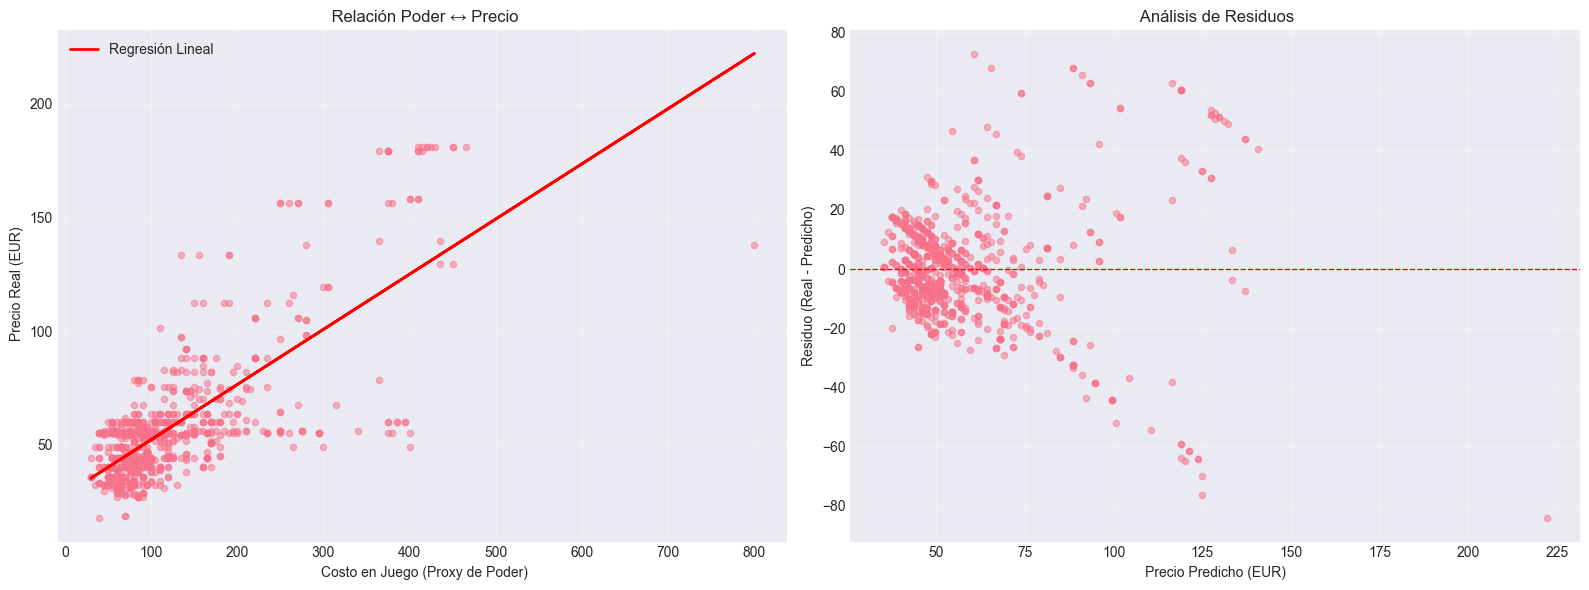

In [312]:
# 6.4 - Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter con línea de regresión
axes[0].scatter(power_price_df['cost'], power_price_df['price'], alpha=0.5, s=20)
axes[0].plot(power_price_df['cost'], model.predict(X), color='red', linewidth=2, label='Regresión Lineal')
axes[0].set_xlabel(' Costo en Juego (Proxy de Poder)')
axes[0].set_ylabel(' Precio Real (EUR)')
axes[0].set_title(' Relación Poder ↔ Precio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuos del modelo (para evaluar calidad predictiva)
power_price_df['predicted_price'] = model.predict(X)
power_price_df['residual'] = power_price_df['price'] - power_price_df['predicted_price']

axes[1].scatter(power_price_df['predicted_price'], power_price_df['residual'], alpha=0.5, s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Precio Predicho (EUR)')
axes[1].set_ylabel('Residuo (Real - Predicho)')
axes[1].set_title(' Análisis de Residuos')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../img/hipotesis_6_power_price.png', dpi=300, bbox_inches='tight')


In [313]:
# 6.5 - Función predictiva
def predict_mini_price(cost_value, faction=None, material=None):
    """
    Predice el precio de una miniatura basado en su costo en juego.
    Ajustes opcionales por facción/material (heurísticos).
    """
    base_price = model.intercept_ + model.coef_[0] * cost_value
    
    # Ajustes heurísticos (basados en promedios observados)
    if faction and faction in df_mini['faction_clean'].unique():
        faction_avg = df_mini[df_mini['faction_clean'] == faction]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= faction_avg / global_avg if pd.notna(faction_avg) else 1
    
    if material and material in df_mini['material'].unique():
        material_avg = df_mini[df_mini['material'] == material]['price'].mean()
        global_avg = df_mini['price'].mean()
        base_price *= material_avg / global_avg if pd.notna(material_avg) else 1
    
    return max(0, base_price)  # Precio no negativo

# Ejemplos de predicción
print("\n Ejemplos de Predicción de Precios:")
test_costs = [50, 100, 150, 200]
for cost in test_costs:
    pred = predict_mini_price(cost)
    print(f"   Costo {cost:3d} pts → Precio estimado: {pred:.2f} EUR")


 Ejemplos de Predicción de Precios:
   Costo  50 pts → Precio estimado: 39.97 EUR
   Costo 100 pts → Precio estimado: 52.12 EUR
   Costo 150 pts → Precio estimado: 64.27 EUR
   Costo 200 pts → Precio estimado: 76.42 EUR


In [314]:
# 6.6 - Evaluación por rangos de poder
power_price_df['power_tier'] = pd.cut(
    power_price_df['cost'],
    bins=[0, 50, 100, 150, 200, 1000],
    labels=['T1: Básico', 'T2: Común', 'T3: Épico', 'T4: Legendario', 'T5: Único']
)

tier_analysis = power_price_df.groupby('power_tier').agg({
    'cost': ['mean', 'std'],
    'price': ['mean', 'std', 'count']
}).round(2)

print("\n Análisis por Tier de Poder:")
print(tier_analysis)


 Análisis por Tier de Poder:
                 cost        price            
                 mean   std   mean   std count
power_tier                                    
T1: Básico      45.00  5.71  41.68 10.17    70
T2: Común       77.78 13.57  46.69 10.31   494
T3: Épico      125.70 14.16  58.92 15.49   172
T4: Legendario 173.45 12.97  65.45 20.39    87
T5: Único      314.09 90.82 105.17 47.93   104


### HIPÓTESIS 7:
#### ¿Existe relación entre el número de entradas del Lore de una figura y su precio?

In [315]:
# 7.1 - Contar entradas de lore por facción
lore_counts = df_lore.groupby('faction').agg({
    'titulo': 'count',
    'serie': 'nunique',
    'year': ['min', 'max']
}).reset_index()
lore_counts.columns = ['faction', 'book_count', 'series_count', 'first_book', 'last_book']
lore_counts['lore_span'] = lore_counts['last_book'] - lore_counts['first_book'] + 1

In [316]:
# 7.2 - Merge con precios de miniaturas
faction_avg_price = df_mini.groupby('faction_clean')['price'].agg(['mean', 'median', 'count']).reset_index()
faction_avg_price.columns = ['faction', 'price_mean', 'price_median', 'mini_count']

lore_price_merge = pd.merge(
    lore_counts,
    faction_avg_price,
    left_on='faction',
    right_on='faction',
    how='inner'
)

In [317]:
# 7.3 - Calcular correlaciones
correlations = {
    'books_vs_price': lore_price_merge['book_count'].corr(lore_price_merge['price_mean']),
    'series_vs_price': lore_price_merge['series_count'].corr(lore_price_merge['price_mean']),
    'lore_span_vs_price': lore_price_merge['lore_span'].corr(lore_price_merge['price_mean'])
}

print("🔗 Correlaciones Lore ↔ Precio:")
for key, value in correlations.items():
    print(f"   {key}: {value:.3f}")

🔗 Correlaciones Lore ↔ Precio:
   books_vs_price: -0.002
   series_vs_price: 0.025
   lore_span_vs_price: -0.143


Facciones analizadas: 27
Outliers eliminados: ['Imperial_Knights', 'Adeptus_Titanicus']


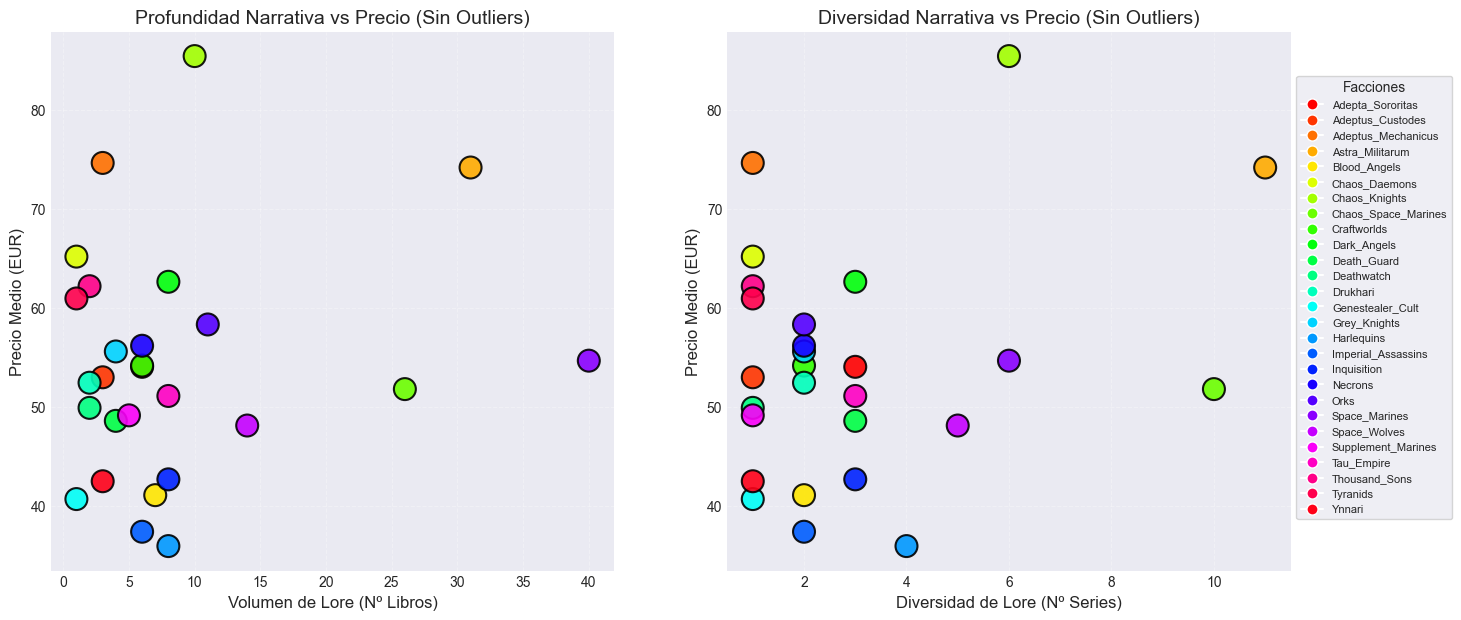

In [350]:
outliers = ['Imperial_Knights', 'Adeptus_Titanicus']
lore_price_clean = lore_price_merge[~lore_price_merge['faction'].isin(outliers)].copy()

print(f"Facciones analizadas: {len(lore_price_clean)}")
print(f"Outliers eliminados: {outliers}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

n_factions = len(lore_price_clean)
if n_factions <= 20:
    colors = plt.cm.tab20(np.linspace(0, 1, n_factions))
else:
    colors = plt.cm.hsv(np.linspace(0, 1, n_factions))

# --- GRÁFICO 1: Volumen de Lore vs Precio ---
axes[0].scatter(
    lore_price_clean['book_count'], 
    lore_price_clean['price_mean'], 
    s=250,                
    alpha=0.9,            
    c=colors, 
    edgecolors='black',   
    linewidth=1.5,
    zorder=5       
)     

axes[0].set_xlabel('Volumen de Lore (Nº Libros)', fontsize=12)
axes[0].set_ylabel('Precio Medio (EUR)', fontsize=12)
axes[0].set_title('Profundidad Narrativa vs Precio (Sin Outliers)', fontsize=14)
axes[0].grid(alpha=0.3, linestyle='--')

# --- GRÁFICO 2: Diversidad de Lore vs Precio ---

axes[1].scatter(
    lore_price_clean['series_count'], 
    lore_price_clean['price_mean'], 
    s=250, 
    alpha=0.9, 
    c=colors, 
    edgecolors='black', 
    linewidth=1.5,
    zorder=5
)

axes[1].set_xlabel('Diversidad de Lore (Nº Series)', fontsize=12)
axes[1].set_ylabel('Precio Medio (EUR)', fontsize=12)
axes[1].set_title('Diversidad Narrativa vs Precio (Sin Outliers)', fontsize=14)
axes[1].grid(alpha=0.3, linestyle='--')

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[i], 
               markersize=8, label=lore_price_clean.iloc[i]['faction'])
    for i in range(n_factions)
]

# Acercamos la leyenda (bbox_to_anchor=1.02) y usamos dos columnas si hay muchas facciones
ncols = 1 if n_factions < 15 else 2

fig.legend(
    handles=legend_handles, 
    loc='center left', 
    bbox_to_anchor=(0.9, 0.5), 
    title="Facciones", 
    fontsize=8, 
    frameon=True
)


plt.savefig('../img/hipotesis_7_lore_price_clean.png', dpi=300, bbox_inches='tight')

In [351]:
# 7.5 - Análisis por facciones destacadas
print("\n RESULTADOS HIPÓTESIS 7:")
print("\n Top Facciones por Profundidad de Lore:")
top_lore = lore_price_merge.nlargest(10, 'book_count')[['faction', 'book_count', 'price_mean', 'mini_count']]
print(top_lore.to_string(index=False))

print("\n Facciones con Mayor Precio vs Lore:")
lore_price_merge['price_per_book'] = lore_price_merge['price_mean'] / (lore_price_merge['book_count'] + 1)
sorted_by_efficiency = lore_price_merge.sort_values('price_per_book', ascending=False)
print(sorted_by_efficiency[['faction', 'book_count', 'price_mean', 'price_per_book']].head(10).to_string(index=False))


 RESULTADOS HIPÓTESIS 7:

 Top Facciones por Profundidad de Lore:
            faction  book_count  price_mean  mini_count
      Space_Marines          40       54.65         153
    Astra_Militarum          31       74.15          49
Chaos_Space_Marines          26       51.78          73
       Space_Wolves          14       48.10          30
               Orks          11       58.31          68
      Chaos_Knights          10       85.41           6
        Dark_Angels           8       62.62          25
         Harlequins           8       35.93          10
        Inquisition           8       42.66           8
         Tau_Empire           8       51.08          37

 Facciones con Mayor Precio vs Lore:
           faction  book_count  price_mean  price_per_book
  Imperial_Knights           3      146.65           36.66
     Chaos_Daemons           1       65.16           32.58
          Tyranids           1       60.93           30.47
     Thousand_Sons           2       62.17 

In [352]:
# 7.6 - Conclusión estadística
r_books_price, p_books_price = stats.pearsonr(
    lore_price_merge['book_count'], 
    lore_price_merge['price_mean']
)
print(f"\n Test Estadístico (Books ↔ Price):")
print(f"   Pearson r = {r_books_price:.3f}, p-value = {p_books_price:.4f}")
print(f"   {' Correlación significativa' if p_books_price < 0.05 else '❌ Sin correlación significativa'}")


 Test Estadístico (Books ↔ Price):
   Pearson r = -0.002, p-value = 0.9901
   ❌ Sin correlación significativa



### HIPÓTESIS 8: Power Creep Analysis
#### ¿Las miniaturas nuevas son "más fuertes por el mismo costo"?


In [338]:
# 8.1 - Preparación de datos: limpiar y normalizar
df_pc = df_mini.copy()
df_pc['year'] = pd.to_numeric(df_pc['year'], errors='coerce')
df_pc['cost'] = pd.to_numeric(df_pc['cost'], errors='coerce')
df_pc['price'] = pd.to_numeric(df_pc['price'], errors='coerce')

# Eliminar filas sin datos esenciales
df_pc = df_pc.dropna(subset=['year', 'cost', 'faction_clean']).copy()

In [339]:
# 8.2 - Métrica clave: "Eficiencia de Poder" = cost / price
# Mayor valor = más puntos de juego por euro = posible power creep
df_pc['power_efficiency'] = df_pc['cost'] / df_pc['price']

In [340]:
# 8.3 - Agrupar por década para análisis macro
df_pc['decade'] = (df_pc['year'] // 10) * 10

In [341]:
# Estadísticas por década
decade_stats = df_pc.groupby('decade').agg({
    'cost': ['mean', 'median', 'std'],
    'price': ['mean', 'median'],
    'power_efficiency': ['mean', 'median'],
    'mini': 'count'
}).round(2)

print(" Evolución de Costo y Eficiencia por Década:")
decade_stats

 Evolución de Costo y Eficiencia por Década:


cost              price        power_efficiency         mini
         mean median   std  mean median             mean median count
decade                                                               
1990   114.36  95.00 63.22 52.25  52.90             2.18   2.12    47
2000   118.62  85.00 98.31 58.12  51.06             1.97   1.90   210
2010   125.54  95.00 83.36 57.45  54.28             2.19   2.01   498
2020   105.29  80.00 65.31 55.12  55.20             1.92   1.66   171

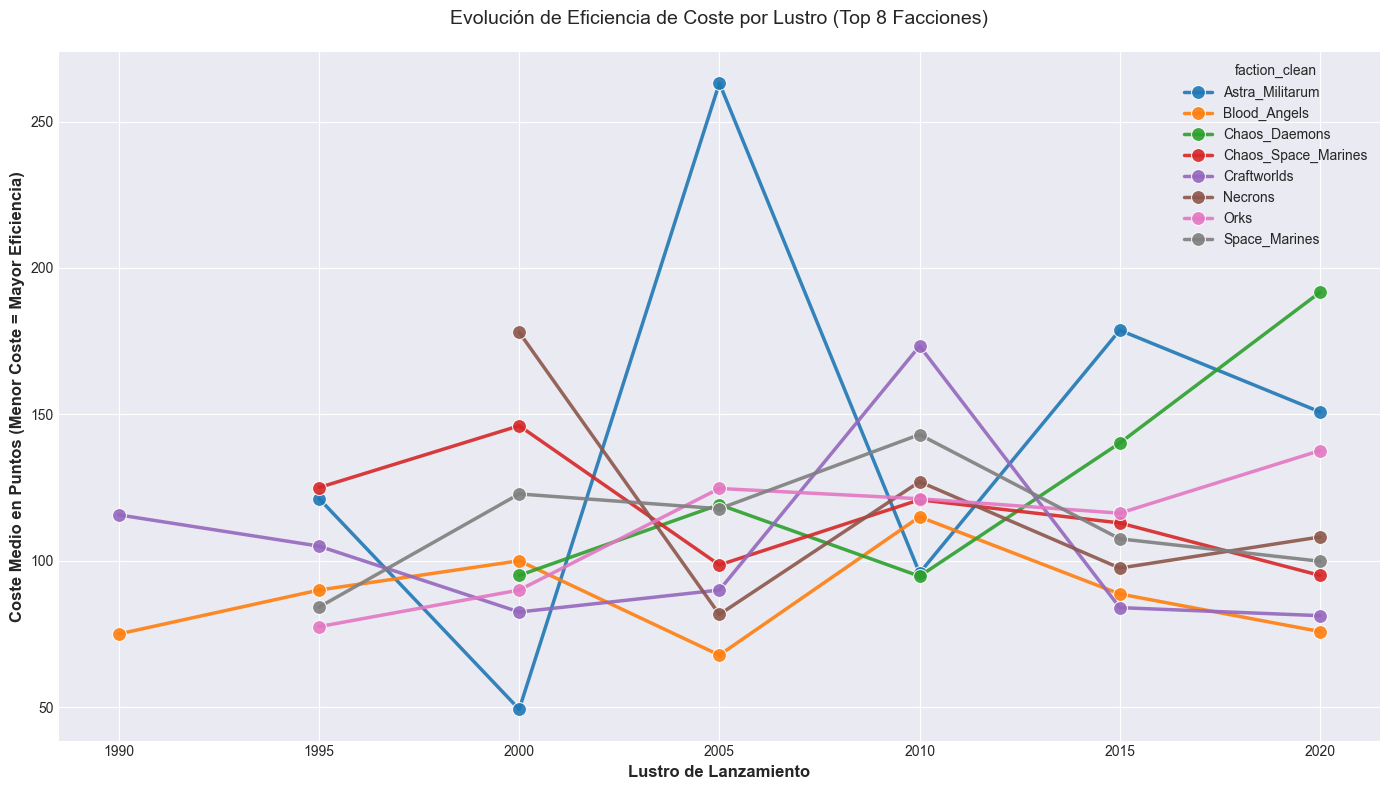

In [358]:

df_pc['lustro'] = (df_pc['year'] // 5) * 5

# 2. Seleccionar las Top 6-8 facciones para no saturar (las que tienen más datos)
top_factions = df_pc['faction_clean'].value_counts().nlargest(8).index
df_top = df_pc[df_pc['faction_clean'].isin(top_factions)]

# 3. Agrupar por Facción y Lustro
agg_data = df_top.groupby(['faction_clean', 'lustro'])['cost'].mean().reset_index()

# Configuración de figura
plt.figure(figsize=(14, 8))

# Usamos lineplot de Seaborn para suavizar y manejar bien la leyenda
sns.lineplot(
    data=agg_data, 
    x='lustro', 
    y='cost', 
    hue='faction_clean', 
    marker='o',        
    markersize=10,      
    linewidth=2.5,    
    palette='tab10',   
    alpha=0.9
)

# Títulos y Etiquetas Claros
plt.xlabel('Lustro de Lanzamiento', fontsize=12, fontweight='bold')
plt.ylabel('Coste Medio en Puntos (Menor Coste = Mayor Eficiencia)', fontsize=12, fontweight='bold')
plt.title('Evolución de Eficiencia de Coste por Lustro (Top 8 Facciones)', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('../img/hipotesis_8_power_creep_lustro.png', dpi=300, bbox_inches='tight')

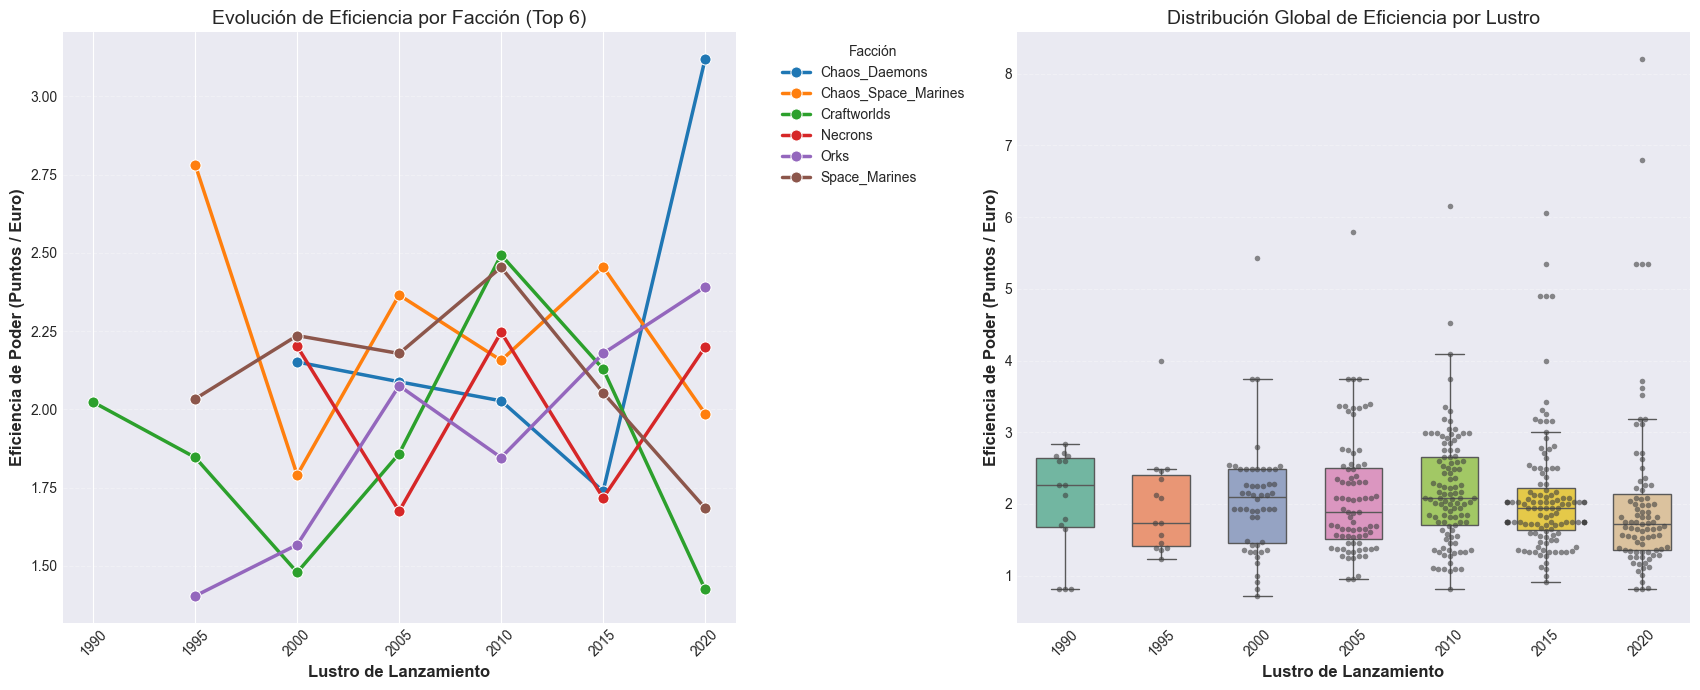

In [369]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- PREPARACIÓN DE DATOS ---
df_pc['lustro'] = (df_pc['year'] // 5) * 5
top_factions = df_pc['faction_clean'].value_counts().nlargest(6).index
df_top = df_pc[df_pc['faction_clean'].isin(top_factions)]

# Agrupar para el gráfico de líneas
efficiency_trend = df_top.groupby(['faction_clean', 'lustro'])['power_efficiency'].mean().reset_index()

# --- CONFIGURACIÓN VISUAL UNIFICADA ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Paleta de colores consistente
palette = sns.color_palette("tab10", n_colors=len(top_factions))

# GRÁFICO 1: TENDENCIA POR FACCION (Líneas)
sns.lineplot(
    data=efficiency_trend, 
    x='lustro', 
    y='power_efficiency', 
    hue='faction_clean', 
    marker='o', 
    markersize=8, 
    linewidth=2.5, 
    palette=palette,
    ax=axes[0]
)

axes[0].set_xlabel('Lustro de Lanzamiento', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Eficiencia de Poder (Puntos / Euro)', fontsize=12, fontweight='bold')
axes[0].set_title('Evolución de Eficiencia por Facción (Top 6)', fontsize=14)
axes[0].legend(title='Facción', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

# GRÁFICO 2: DISTRIBUCIÓN GLOBAL (Box + Swarm)

# Usamos boxplot para ver la mediana/rango y swarm para ver los datos reales
sns.boxplot(data=df_top, x='lustro', y='power_efficiency', ax=axes[1], 
            palette="Set2", width=0.6, showfliers=False) # showfliers=False para limpieza

sns.swarmplot(data=df_top, x='lustro', y='power_efficiency', ax=axes[1], 
              color=".25", size=4, alpha=0.6)

axes[1].set_xlabel('Lustro de Lanzamiento', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Eficiencia de Poder (Puntos / Euro)', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución Global de Eficiencia por Lustro', fontsize=14)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

# Ajuste final para que no se solapen
plt.tight_layout(rect=[0, 0, 0.95, 1]) # Dejamos espacio a la derecha para la leyenda del gráfico 1

plt.savefig('../img/hipotesis_8_efficiency_combined.png', dpi=300, bbox_inches='tight')
plt.show()

In [370]:
# 8.6 - Análisis por "rol" aproximado usando rangos de base_mm2 y cost
# Clasificación heurística de tipos de unidad
def classify_unit_role(row):
    """Clasificación aproximada por tamaño de base y costo"""
    base = str(row.get('base_mm2', ''))
    cost = row.get('cost', 0)
    
    # Extraer valor numérico de base
    try:
        base_num = float(''.join(filter(str.isdigit, base.split()[0]))) if base else 25
    except:
        base_num = 25
    
    if base_num <= 32 and cost < 100:
        return 'Infantería Ligera'
    elif base_num <= 40 and cost < 150:
        return 'Infantería Pesada'
    elif base_num > 60 or cost > 200:
        return 'Monstruo/Vehículo'
    elif 40 <= base_num <= 60:
        return 'Élite'
    else:
        return 'Soporte'

df_pc['unit_role'] = df_pc.apply(classify_unit_role, axis=1)

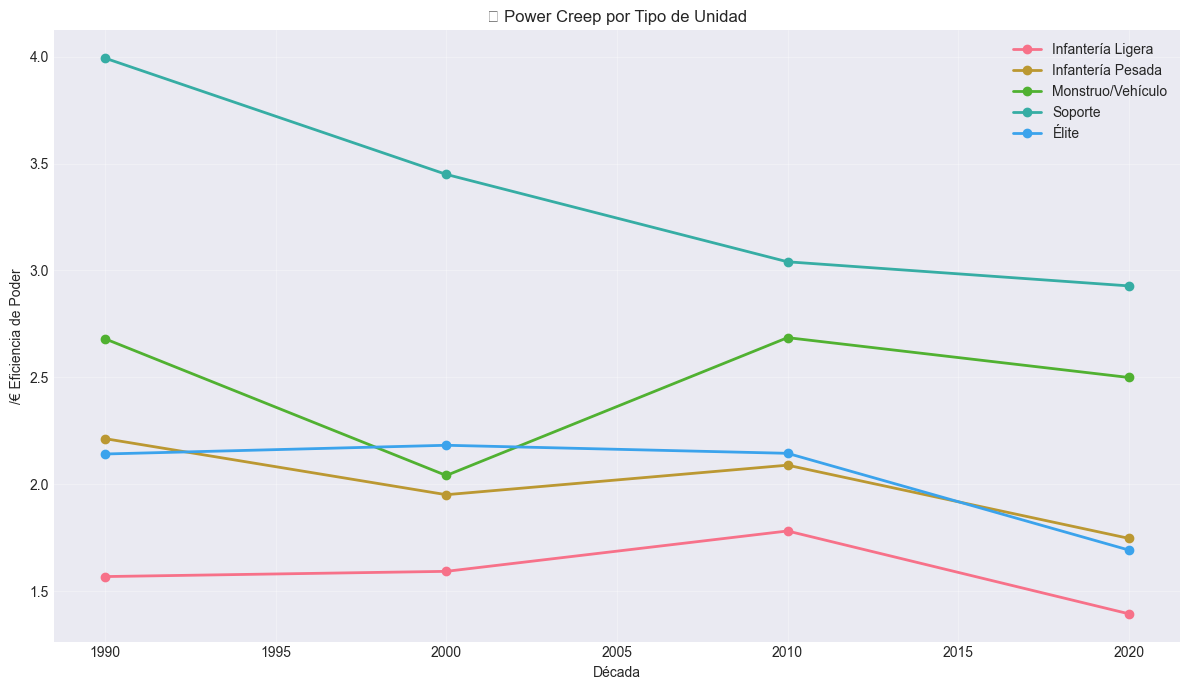

In [372]:
# 8.7 - Power creep por rol de unidad
role_trends = df_pc.groupby(['decade', 'unit_role'])['power_efficiency'].mean().unstack()

plt.figure(figsize=(12, 7))
for role in role_trends.columns:
    plt.plot(role_trends.index, role_trends[role], 
             marker='o', label=role, linewidth=2)

plt.xlabel('Década')
plt.ylabel('/€ Eficiencia de Poder')
plt.title('🎭 Power Creep por Tipo de Unidad')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../img/hipotesis_8_creep_by_role.png', dpi=300, bbox_inches='tight')


In [373]:
# 8.8 - Test estadístico: ¿Cambio significativo en eficiencia entre décadas?
from scipy.stats import ttest_ind

decade_2000 = df_pc[df_pc['decade'] == 2000]['power_efficiency'].dropna()
decade_2020 = df_pc[df_pc['decade'] == 2020]['power_efficiency'].dropna()

if len(decade_2000) > 10 and len(decade_2020) > 10:
    t_stat, p_value = ttest_ind(decade_2020, decade_2000, equal_var=False)
    effect_size = (decade_2020.mean() - decade_2000.mean()) / decade_2000.std()
    
    print("\n TEST ESTADÍSTICO: Power Creep 2000s vs 2020s")
    print(f"   Eficiencia media 2000s: {decade_2000.mean():.3f} /€")
    print(f"   Eficiencia media 2020s: {decade_2020.mean():.3f} /€")
    print(f"   Diferencia: {decade_2020.mean() - decade_2000.mean():+.3f} /€")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   Effect size (Cohen's d): {effect_size:.3f}")
    print(f"    {'Power creep detectado' if p_value < 0.05 and effect_size > 0.2 else '❌ Sin evidencia clara de power creep'}")



 TEST ESTADÍSTICO: Power Creep 2000s vs 2020s
   Eficiencia media 2000s: 1.973 /€
   Eficiencia media 2020s: 1.919 /€
   Diferencia: -0.055 /€
   t-statistic: -0.569, p-value: 0.5699
   Effect size (Cohen's d): -0.068
    ❌ Sin evidencia clara de power creep


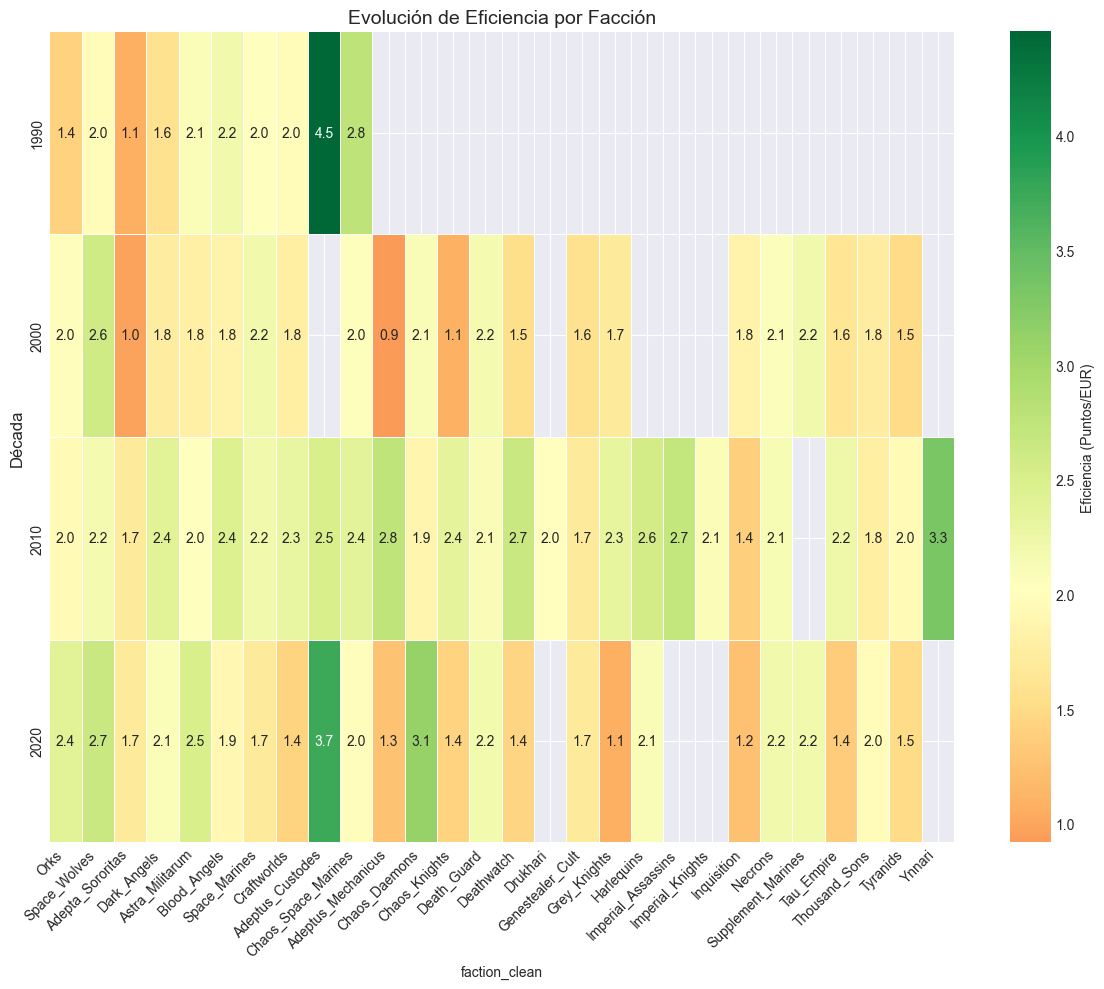

In [383]:
faction_efficiency_change = df_pc.groupby(['faction_clean', 'decade'])['power_efficiency'].mean().unstack()

# 2. Calcular cambio neto para ordenar
faction_efficiency_change['net_change'] = faction_efficiency_change.iloc[:, -1] - faction_efficiency_change.iloc[:, 0]

# Ordenar facciones por su mejora neta
sorted_factions = faction_efficiency_change.sort_values('net_change', ascending=False)
top_data = sorted_factions.drop(columns='net_change')

# Filtramos los NaNs para que no afecten al cálculo del centro
valid_values = top_data.values[~np.isnan(top_data.values)]
vcenter_val = np.median(valid_values)

plt.figure(figsize=(12, 10))

# 4. Plotear Heatmap con el centro corregido
sns.heatmap(
    top_data.T, 
    cmap='RdYlGn',       
    center=vcenter_val,
    annot=True, 
    fmt='.1f',
    linewidths=.5,
    cbar_kws={'label': 'Eficiencia (Puntos/EUR)'}
)

plt.ylabel('Década', fontsize=12)
plt.title(f'Evolución de Eficiencia por Facción', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('../img/hipotesis_8_faction_creep_heatmap_fixed.png', dpi=300, bbox_inches='tight')

In [384]:
# 8.10 - Función utilitaria: Detectar posibles casos de power creep extremo
def find_power_creep_outliers(threshold_std=2):
    """
    Identifica miniaturas con eficiencia de poder anormalmente alta
    para su año de lanzamiento
    """
    df_outliers = df_pc.copy()
    
    # Calcular z-score por año
    df_outliers['efficiency_zscore'] = df_outliers.groupby('year')['power_efficiency'].transform(
        lambda x: (x - x.mean()) / x.std() if x.std() > 0 else 0
    )
    
    # Filtrar outliers positivos (posible power creep)
    outliers = df_outliers[
        (df_outliers['efficiency_zscore'] > threshold_std) & 
        (df_outliers['year'] >= 2015)  # Solo miniaturas recientes
    ].sort_values('efficiency_zscore', ascending=False)
    
    return outliers[['mini', 'faction_clean', 'year', 'cost', 'price', 'power_efficiency', 'efficiency_zscore']]

# Ejecutar y mostrar resultados
creep_outliers = find_power_creep_outliers()

print("\n🚨 POSIBLES CASOS DE POWER CREEP (Eficiencia > 2σ sobre media anual):")
if not creep_outliers.empty:
    print(creep_outliers.head(15).to_string(index=False))
else:
    print("   No se detectaron outliers significativos con el umbral actual.")



🚨 POSIBLES CASOS DE POWER CREEP (Eficiencia > 2σ sobre media anual):
                 mini       faction_clean  year   cost  price  power_efficiency  efficiency_zscore
              SZAREKH             Necrons  2020 400.00  48.76              8.20               5.67
             Be'lakor       Chaos_Daemons  2021 375.00  55.20              6.79               5.33
            Mortarion         Death_Guard  2017 380.00  55.20              6.88               4.66
      Knight Rampager       Chaos_Knights  2019 365.00  78.20              4.67               3.92
    Roboute Guilliman       Space_Marines  2017 340.00  56.12              6.06               3.85
       Lion El'jonson         Dark_Angels  2023 315.00  67.62              4.66               3.85
           Stormsurge     Astra_Militarum  2015 400.00  55.20              7.25               3.46
              Praetor Chaos_Space_Marines  2018 275.00  56.12              4.90               3.32
              Praetor Chaos_Space_Marin

### HIPÓTESIS 9: Value Efficiency Analysis
#### ¿Pagamos por plástico o por marca?

In [385]:
# 9.1 - Preparación de datos: extraer valor numérico de base_mm2
df_ve = df_mini.copy()

def extract_base_size(base_str):
    """Extrae el valor numérico principal de campos como '40mm', '120 x 92mm', etc."""
    if pd.isna(base_str) or base_str == '':
        return np.nan
    if isinstance(base_str, (int, float)):
        return float(base_str)
    
    # Limpiar string
    base_str = str(base_str).strip().lower()
    
    # Caso especial: "Use model" o similares
    if 'use model' in base_str or 'flying' in base_str:
        return np.nan
    
    # Extraer números: priorizar el primero (dimensión principal)
    numbers = re.findall(r'(\d+(?:\.\d+)?)', base_str)
    if numbers:
        return float(numbers[0])
    return np.nan

In [386]:
df_ve['base_size_num'] = df_ve['base_mm2'].apply(extract_base_size)

# Calcular área aproximada (asumiendo base circular: π*r²)
df_ve['base_radius'] = df_ve['base_size_num'] / 2
df_ve['base_area_mm2'] = np.pi * (df_ve['base_radius'] ** 2)

# 9.2 - Calcular métrica clave: "Precio por mm²" (Value Efficiency)
df_ve_clean = df_ve.dropna(subset=['price', 'base_area_mm2']).copy()
df_ve_clean = df_ve_clean[df_ve_clean['base_area_mm2'] > 0].copy()  # Eliminar áreas inválidas

df_ve_clean['price_per_mm2'] = df_ve_clean['price'] / df_ve_clean['base_area_mm2']
df_ve_clean['cost_per_mm2'] = df_ve_clean['cost'] / df_ve_clean['base_area_mm2']  # Poder por área

print(f" Datos válidos para análisis: {len(df_ve_clean)} miniaturas")
print(f"\n Estadísticas de Precio por mm²:")
print(df_ve_clean['price_per_mm2'].describe())

 Datos válidos para análisis: 771 miniaturas

 Estadísticas de Precio por mm²:
count   771.00
mean      0.04
std       0.03
min       0.00
25%       0.02
50%       0.04
75%       0.06
max       0.12
Name: price_per_mm2, dtype: float64


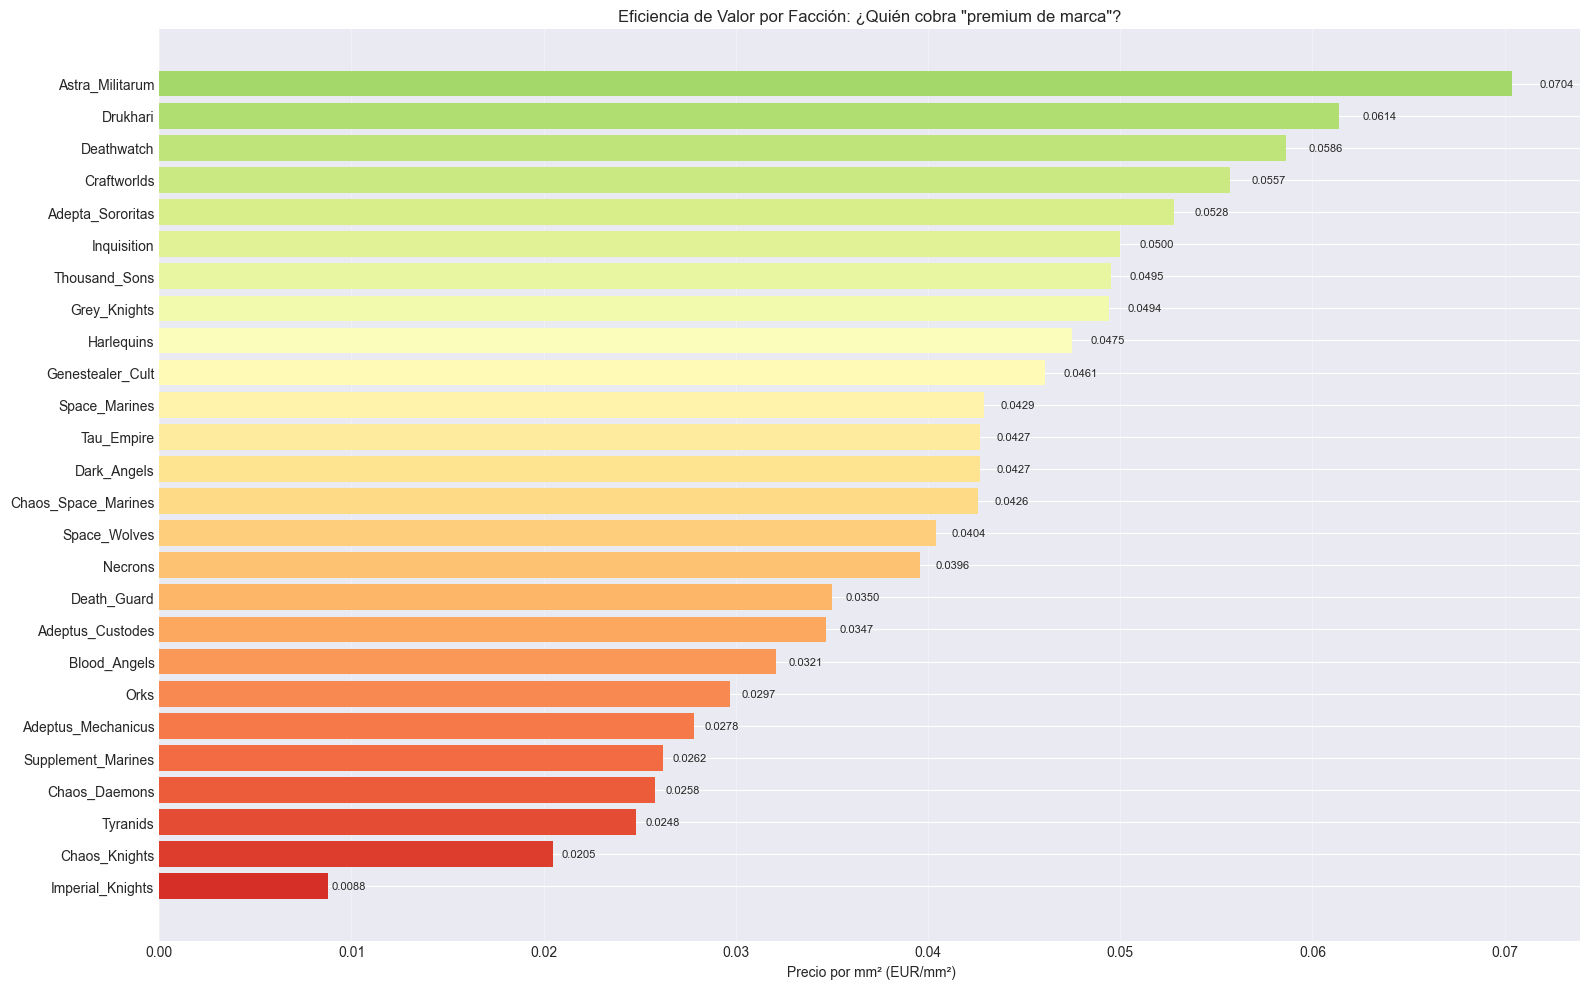

In [389]:
# 9.3 - Visualización 1: Distribución de price_per_mm2 por facción
plt.figure(figsize=(16, 10))
# Calcular estadísticas por facción
faction_efficiency = df_ve_clean.groupby('faction_clean').agg({
    'price_per_mm2': ['mean', 'median', 'std', 'count'],
    'price': 'mean',
    'base_area_mm2': 'mean'
}).round(4)
faction_efficiency.columns = ['ppm2_mean', 'ppm2_median', 'ppm2_std', 'count', 'price_mean', 'area_mean']
faction_efficiency = faction_efficiency[faction_efficiency['count'] >= 5]  # Mínimo de muestras

# Ordenar por precio por mm² medio
sorted_factions = faction_efficiency.sort_values('ppm2_mean', ascending=False)

# Gráfico de barras horizontal
bars = plt.barh(sorted_factions.index, sorted_factions['ppm2_mean'], 
                color=plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(sorted_factions))))

plt.xlabel(' Precio por mm² (EUR/mm²)')
plt.title('Eficiencia de Valor por Facción: ¿Quién cobra "premium de marca"?')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)

# Añadir labels con valores
for bar, faction in zip(bars, sorted_factions.index):
    width = bar.get_width()
    if width > 0:
        plt.text(width * 1.02, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../img/hipotesis_9_value_efficiency_by_faction.png', dpi=300, bbox_inches='tight')


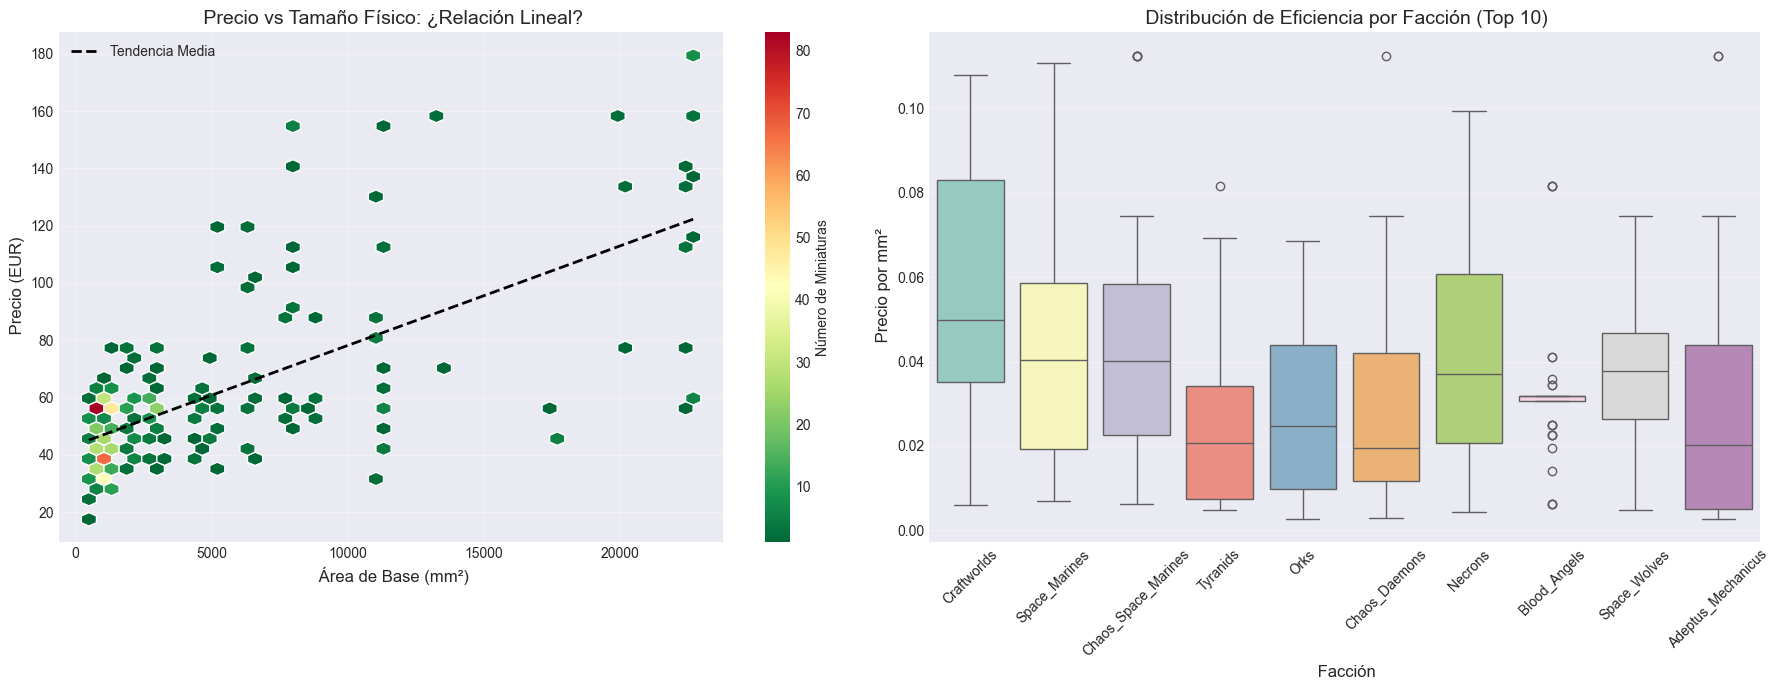

In [412]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- GRÁFICO 1: Mapa de Densidad Hexagonal (Escala Lineal) ---
hb = axes[0].hexbin(
    df_ve_clean['base_area_mm2'], 
    df_ve_clean['price'], 
    gridsize=40,          # Ajusta este número: más alto = hexágonos más pequeños y detallados
    cmap='RdYlGn_r',      # Rojo (Muchas miniaturas) -> Verde (Pocas miniaturas)
    mincnt=1,             # Solo pinta si hay al menos 1 dato
    edgecolors='white'    # Borde blanco para separar bien los hexágonos
)

axes[0].set_xlabel(' Área de Base (mm²)', fontsize=12)
axes[0].set_ylabel(' Precio (EUR)', fontsize=12)
axes[0].set_title(' Precio vs Tamaño Físico: ¿Relación Lineal?', fontsize=14)

cbar = plt.colorbar(hb, ax=axes[0])
cbar.set_label('Número de Miniaturas')

# Línea de tendencia lineal simple
if len(df_ve_clean) > 2:
    z = np.polyfit(df_ve_clean['base_area_mm2'].dropna(), 
                   df_ve_clean['price'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_ve_clean['base_area_mm2'].min(), 
                         df_ve_clean['base_area_mm2'].max(), 100)
    axes[0].plot(x_line, p(x_line), "k--", linewidth=2, label=f'Tendencia Media')

axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# --- GRÁFICO 2: Boxplot de Eficiencia (Sin cambios) ---
top_factions = df_ve_clean['faction_clean'].value_counts().nlargest(10).index
subset = df_ve_clean[df_ve_clean['faction_clean'].isin(top_factions)]

sns.boxplot(data=subset, x='faction_clean', y='price_per_mm2', ax=axes[1], palette="Set3")
axes[1].set_xlabel(' Facción', fontsize=12)
axes[1].set_ylabel(' Precio por mm²', fontsize=12)
axes[1].set_title(' Distribución de Eficiencia por Facción (Top 10)', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/hipotesis_9_hexbin_linear.png', dpi=300, bbox_inches='tight')
plt.show()

In [413]:
# 9.5 - Identificar "Premium de Marca": facciones con price_per_mm2 significativamente alto
global_mean = df_ve_clean['price_per_mm2'].mean()
global_std = df_ve_clean['price_per_mm2'].std()

# Calcular z-score por facción
faction_zscores = {}
for faction in faction_efficiency.index:
    faction_data = df_ve_clean[df_ve_clean['faction_clean'] == faction]['price_per_mm2']
    if len(faction_data) >= 5:
        z = (faction_data.mean() - global_mean) / global_std
        faction_zscores[faction] = {
            'z_score': z,
            'mean_ppm2': faction_data.mean(),
            'count': len(faction_data),
            'premium_pct': (faction_data.mean() / global_mean - 1) * 100
        }

premium_df = pd.DataFrame(faction_zscores).T
premium_df = premium_df.sort_values('z_score', ascending=False)

print("\n ANÁLISIS DE PREMIUM DE MARCA:")
print(f"   Media global: {global_mean:.5f} EUR/mm²")
print(f"   Desviación: {global_std:.5f} EUR/mm²\n")

print(" Facciones con MAYOR Premium (cobran más por mm²):")
print(premium_df[premium_df['z_score'] > 0].head(8)[['z_score', 'mean_ppm2', 'premium_pct', 'count']]
      .round(3).to_string())

print("\n💎 Facciones con MENOR Premium (mejor valor por mm²):")
print(premium_df[premium_df['z_score'] < 0].tail(8)[['z_score', 'mean_ppm2', 'premium_pct', 'count']]
      .round(3).to_string())



 ANÁLISIS DE PREMIUM DE MARCA:
   Media global: 0.04017 EUR/mm²
   Desviación: 0.02669 EUR/mm²

 Facciones con MAYOR Premium (cobran más por mm²):
                  z_score  mean_ppm2  premium_pct  count
Astra_Militarum      1.13       0.07        75.24  27.00
Drukhari             0.80       0.06        52.83  16.00
Deathwatch           0.69       0.06        45.84   7.00
Craftworlds          0.58       0.06        38.59  45.00
Adepta_Sororitas     0.47       0.05        31.57  28.00
Inquisition          0.37       0.05        24.61   8.00
Thousand_Sons        0.35       0.05        23.28  13.00
Grey_Knights         0.34       0.05        22.93  17.00

💎 Facciones con MENOR Premium (mejor valor por mm²):
                    z_score  mean_ppm2  premium_pct  count
Blood_Angels          -0.30       0.03       -20.18  48.00
Orks                  -0.39       0.03       -25.93  55.00
Adeptus_Mechanicus    -0.46       0.03       -30.79  36.00
Supplement_Marines    -0.52       0.03       -34.

In [414]:
# 9.6 - Test estadístico: ¿Diferencias significativas entre facciones?
from scipy.stats import f_oneway, ttest_ind

# Comparar top 3 vs bottom 3 en premium
top_premium = premium_df[premium_df['z_score'] > 0].head(3).index
bottom_premium = premium_df[premium_df['z_score'] < 0].tail(3).index

if len(top_premium) >= 2 and len(bottom_premium) >= 2:
    top_data = df_ve_clean[df_ve_clean['faction_clean'].isin(top_premium)]['price_per_mm2']
    bottom_data = df_ve_clean[df_ve_clean['faction_clean'].isin(bottom_premium)]['price_per_mm2']
    
    t_stat, p_value = ttest_ind(top_data, bottom_data, equal_var=False)
    effect_size = (top_data.mean() - bottom_data.mean()) / np.sqrt((top_data.std()**2 + bottom_data.std()**2)/2)
    
    print(f"\n TEST T: Premium Top vs Bottom")
    print(f"   Top Premium mean: {top_data.mean():.5f} EUR/mm²")
    print(f"   Bottom Premium mean: {bottom_data.mean():.5f} EUR/mm²")
    print(f"   Diferencia: {top_data.mean() - bottom_data.mean():+.5f} EUR/mm²")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   Effect size (Cohen's d): {effect_size:.3f}")
    print(f"    {'Diferencia ALTAMENTE significativa' if p_value < 0.01 else '❌ Sin diferencia clara'}")


 TEST T: Premium Top vs Bottom
   Top Premium mean: 0.06585 EUR/mm²
   Bottom Premium mean: 0.02111 EUR/mm²
   Diferencia: +0.04474 EUR/mm²
   t-statistic: 8.699, p-value: 0.0000
   Effect size (Cohen's d): 1.740
    Diferencia ALTAMENTE significativa



 ANÁLISIS POR TIER DE TAMAÑO:
                 price_per_mm2        price base_area_mm2       faction_clean
                          mean median  mean          mean            <lambda>
size_tier                                                                    
Tiny (<25mm)              0.09   0.10 44.92        490.87     Astra_Militarum
Small (25-40mm)           0.05   0.04 46.79       1120.41       Space_Marines
Medium (40-60mm)          0.02   0.02 54.68       3186.05       Space_Marines
Large (60-90mm)           0.01   0.01 76.74       6820.19       Space_Marines
Huge (90mm+)              0.01   0.01 97.57      17042.00  Adeptus_Mechanicus


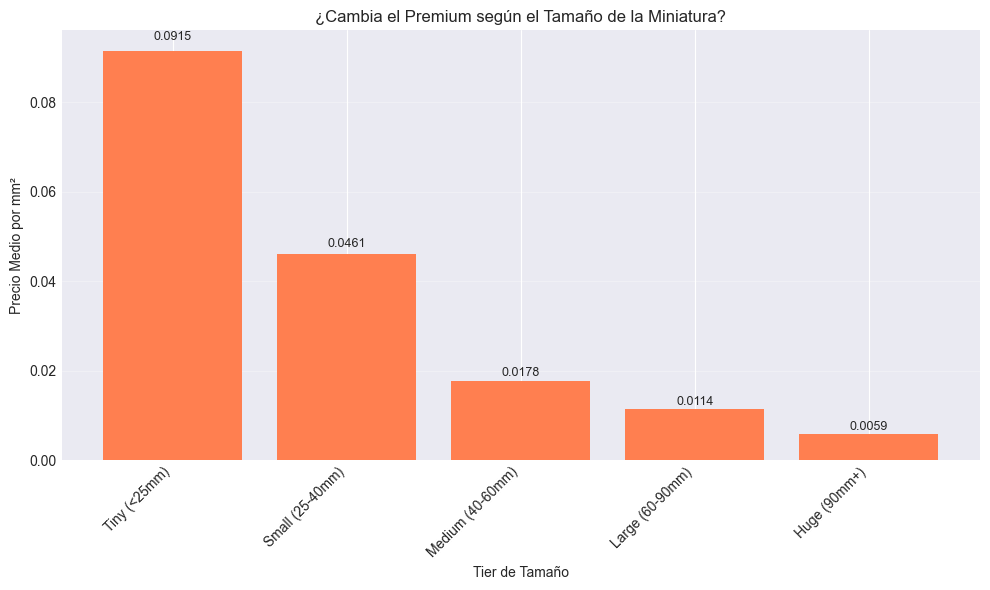

In [417]:
# 9.7 - Análisis por "tier de tamaño": ¿El premium cambia con el tamaño?
df_ve_clean['size_tier'] = pd.cut(
    df_ve_clean['base_area_mm2'],
    bins=[0, 500, 2000, 5000, 10000, 100000],
    labels=['Tiny (<25mm)', 'Small (25-40mm)', 'Medium (40-60mm)', 'Large (60-90mm)', 'Huge (90mm+)']
)

tier_analysis = df_ve_clean.groupby('size_tier').agg({
    'price_per_mm2': ['mean', 'median'],
    'price': 'mean',
    'base_area_mm2': 'mean',
    'faction_clean': lambda x: x.value_counts().index[0] if len(x) > 0 else 'N/A'
}).round(3)

print("\n ANÁLISIS POR TIER DE TAMAÑO:")
print(tier_analysis)

# Visualizar tier analysis
plt.figure(figsize=(10, 6))
tier_means = df_ve_clean.groupby('size_tier')['price_per_mm2'].mean()
bars = plt.bar(tier_means.index.astype(str), tier_means.values, color='coral')

plt.xlabel('Tier de Tamaño')
plt.ylabel('Precio Medio por mm²')
plt.title('¿Cambia el Premium según el Tamaño de la Miniatura?')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Añadir valores en barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height * 1.02, 
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../img/hipotesis_9_premium_by_size_tier.png', dpi=300, bbox_inches='tight')



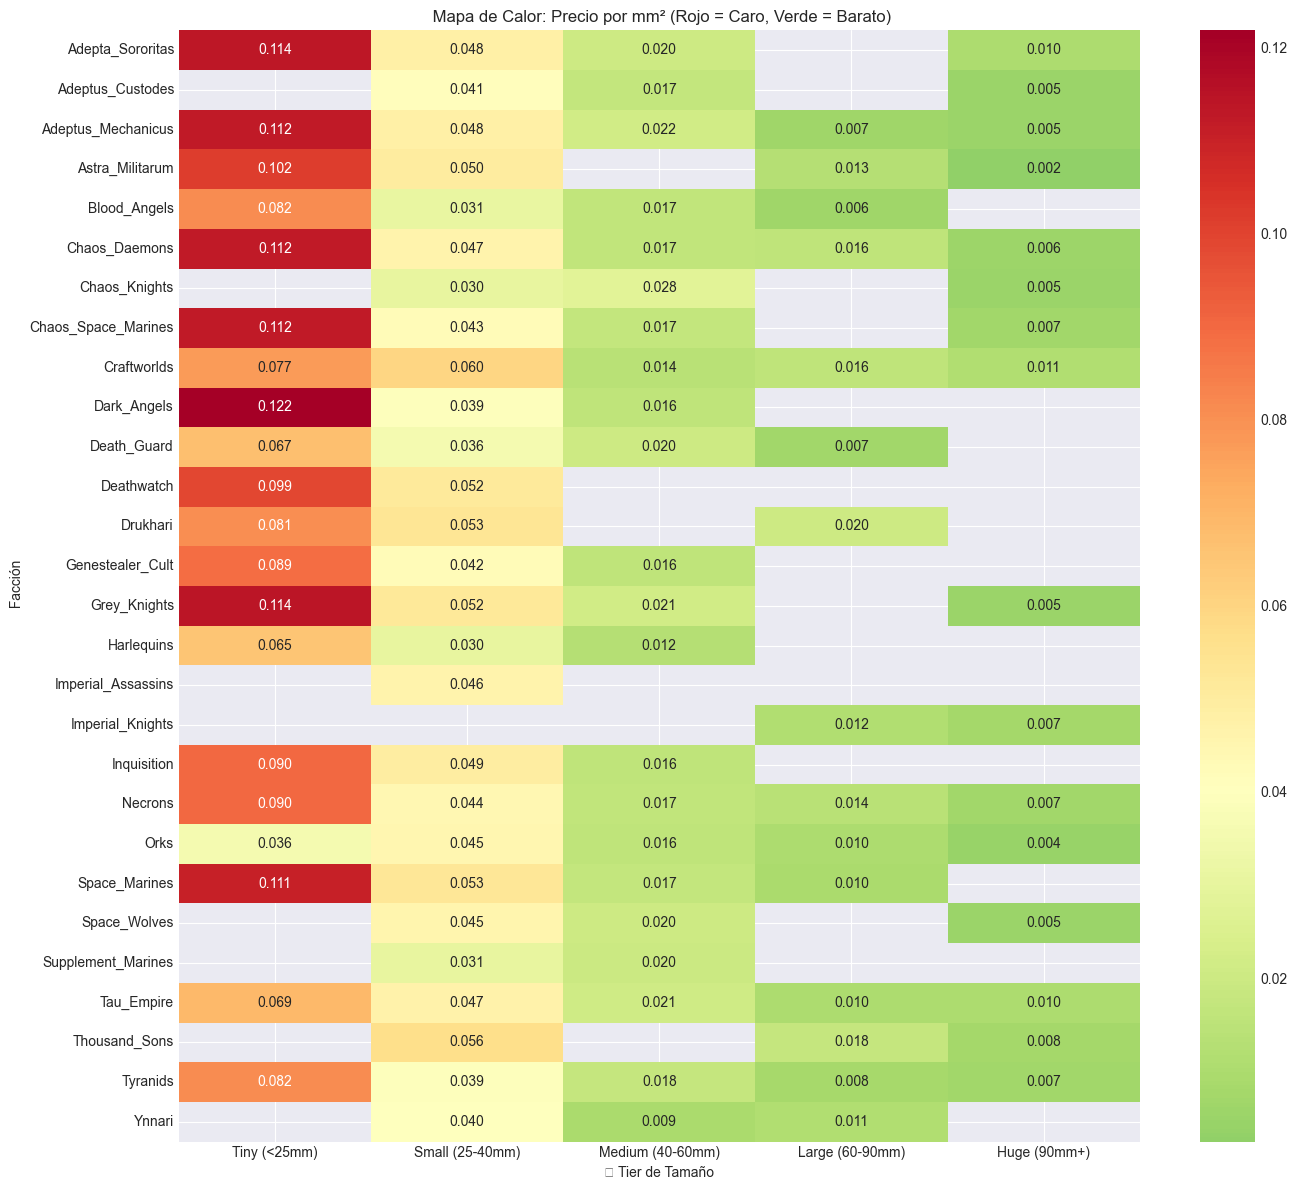

In [418]:
# 9.8 - Heatmap: Facción x Tier de Tamaño (precio por mm²)
heatmap_data = df_ve_clean.pivot_table(
    values='price_per_mm2', 
    index='faction_clean', 
    columns='size_tier', 
    aggfunc='mean'
)

plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_data.dropna(how='all', axis=0).dropna(how='all', axis=1), 
            annot=True, fmt='.3f', cmap='RdYlGn_r', center=global_mean)
plt.xlabel('📏 Tier de Tamaño')
plt.ylabel(' Facción')
plt.title(' Mapa de Calor: Precio por mm² (Rojo = Caro, Verde = Barato)')
plt.tight_layout()
plt.savefig('../img/hipotesis_9_heatmap_faction_size.png', dpi=300, bbox_inches='tight')


In [419]:
# 9.9 - Función utilitaria: ¿Vale la pena esta miniatura?
def evaluate_mini_value(mini_name, faction=None, target_price=None):
    """
    Evalúa si una miniatura específica tiene buen valor comparado con su facción.
    """
    # Buscar miniatura
    if faction:
        results = df_ve_clean[
            (df_ve_clean['mini'].str.contains(mini_name, case=False, na=False)) & 
            (df_ve_clean['faction_clean'] == faction)
        ]
    else:
        results = df_ve_clean[
            df_ve_clean['mini'].str.contains(mini_name, case=False, na=False)
        ]
    
    if results.empty:
        return f"❌ No se encontró '{mini_name}'{f' en {faction}' if faction else ''}"
    
    mini = results.iloc[0]
    faction_avg = df_ve_clean[df_ve_clean['faction_clean'] == mini['faction_clean']]['price_per_mm2'].mean()
    
    value_score = faction_avg / mini['price_per_mm2']  # >1 = buen valor, <1 = caro
    
    return f"""
    🔍 Evaluación: {mini['mini']} ({mini['faction_clean']})
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: {mini['base_area_mm2']:.0f} mm²
    💰 Precio actual: €{mini['price']:.2f}
    ⚡ Precio por mm²: {mini['price_per_mm2']:.5f} EUR/mm²
    📊 Promedio facción: {faction_avg:.5f} EUR/mm²

    🎯 Valor relativo: {value_score:.2f}x
    {'✅ BUEN VALOR' if value_score > 1.1 else '⚖️ PRECIO JUSTO' if value_score > 0.9 else '❌ PREMIUM ALTO'}

    💡 Consejo: {'¡Aprovéchalo!' if value_score > 1.2 else 'Precio estándar' if value_score > 0.85 else 'Espera oferta/re-edición'}
    """

In [420]:
# Ejemplos de uso
print("\n EJEMPLOS DE EVALUACIÓN DE VALOR:")
print(evaluate_mini_value("Wraithknight", "Craftworlds"))
print(evaluate_mini_value("Tactical Squad", "Space_Marines"))


 EJEMPLOS DE EVALUACIÓN DE VALOR:

    🔍 Evaluación: Wraithknight (Craftworlds)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: 11310 mm²
    💰 Precio actual: €129.72
    ⚡ Precio por mm²: 0.01147 EUR/mm²
    📊 Promedio facción: 0.05567 EUR/mm²

    🎯 Valor relativo: 4.85x
    ✅ BUEN VALOR

    💡 Consejo: ¡Aprovéchalo!
    

    🔍 Evaluación: Tactical Squad (Space_Marines)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    📐 Área de base: 804 mm²
    💰 Precio actual: €46.00
    ⚡ Precio por mm²: 0.05720 EUR/mm²
    📊 Promedio facción: 0.04289 EUR/mm²

    🎯 Valor relativo: 0.75x
    ❌ PREMIUM ALTO

    💡 Consejo: Espera oferta/re-edición
    


### HIPÓTESIS 10: ¿Las facciones con más "Primary" players tienen mejor soporte?
#### ¿Games Workshop prioriza facciones con base de jugadores leales?

In [421]:
# 10.1 - Preparación de métricas de "lealtad" y "soporte"
# Lealtad = Primary / Owned (proporción de jugadores que la usan como principal)
df_faction_clean = df_faction.copy()

# Limpiar datos numéricos
for col in ['Owned', 'Primary', 'Games', 'Win %', 'Real Win %']:
    df_faction_clean[col] = pd.to_numeric(
        df_faction_clean[col].astype(str).str.replace(',', '.'), 
        errors='coerce'
    )

# Calcular métrica de lealtad
df_faction_clean['loyalty_ratio'] = df_faction_clean['Primary'] / df_faction_clean['Owned']
df_faction_clean = df_faction_clean.dropna(subset=['loyalty_ratio', 'Owned', 'Primary'])

In [422]:
# 10.2 - Merge con métricas de soporte (cantidad de miniaturas, ediciones soportadas)
faction_support = df_mini.groupby('faction_clean').agg({
    'mini': 'count',  # Cantidad de miniaturas = proxy de soporte
    'edition': 'nunique',  # Ediciones soportadas
    'year': ['min', 'max'],  # Rango temporal de soporte
    'price': 'mean'  # Precio promedio
}).reset_index()
faction_support.columns = ['faction', 'mini_count', 'editions_supported', 'first_year', 'last_year', 'price_avg']

# Calcular años de soporte activo
faction_support['support_years'] = faction_support['last_year'] - faction_support['first_year'] + 1
faction_support['mini_per_year'] = faction_support['mini_count'] / faction_support['support_years']

# Merge con datos de lealtad
loyalty_support_merge = pd.merge(
    df_faction_clean[['faction_clean', 'Owned', 'Primary', 'loyalty_ratio', 'Games', 'Real Win %']],
    faction_support,
    left_on='faction_clean',
    right_on='faction',
    how='inner'
)

print(f" Datos válidos para análisis de lealtad: {len(loyalty_support_merge)} facciones")
print(f"\n Estadísticas de Lealtad:")
print(loyalty_support_merge['loyalty_ratio'].describe())

 Datos válidos para análisis de lealtad: 14 facciones

 Estadísticas de Lealtad:
count   14.00
mean     0.21
std      0.08
min      0.05
25%      0.18
50%      0.20
75%      0.28
max      0.31
Name: loyalty_ratio, dtype: float64


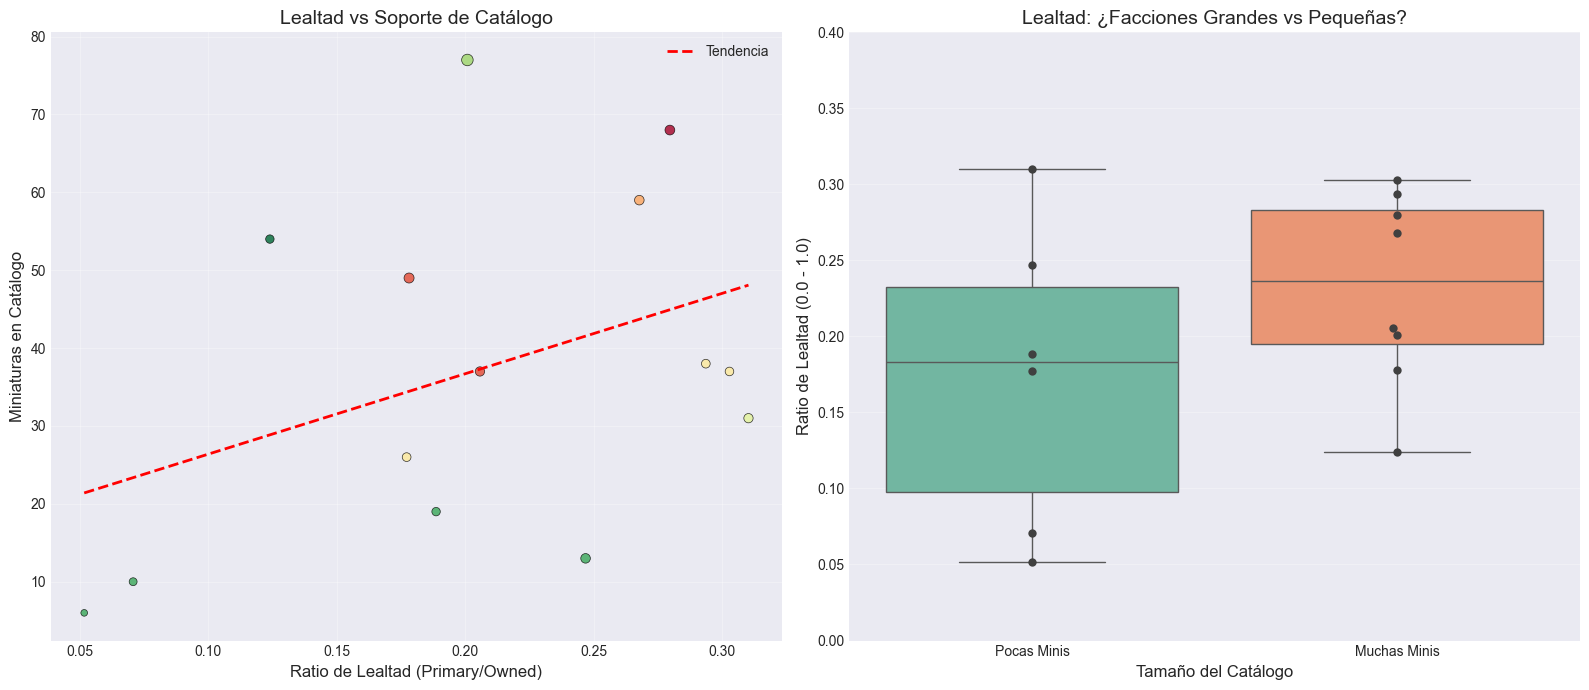

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRÁFICO 1: Scatter Plot (Correcto) ---
axes[0].scatter(
    loyalty_support_merge['loyalty_ratio'],
    loyalty_support_merge['mini_count'],
    s=loyalty_support_merge['Owned'] / 10, 
    c=loyalty_support_merge['Real Win %'],
    cmap='RdYlGn', alpha=0.8, edgecolors='black', linewidth=0.5
)

axes[0].set_xlabel('Ratio de Lealtad (Primary/Owned)', fontsize=12)
axes[0].set_ylabel('Miniaturas en Catálogo', fontsize=12)
axes[0].set_title('Lealtad vs Soporte de Catálogo', fontsize=14)
axes[0].grid(alpha=0.3)

# Línea de tendencia
if len(loyalty_support_merge) > 2:
    z = np.polyfit(loyalty_support_merge['loyalty_ratio'], loyalty_support_merge['mini_count'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(loyalty_support_merge['loyalty_ratio'].min(), 
                         loyalty_support_merge['loyalty_ratio'].max(), 100)
    axes[0].plot(x_line, p(x_line), "r--", linewidth=2, label='Tendencia')
    axes[0].legend()

# --- GRÁFICO 2: Boxplot CORREGIDO (Solo 2 Categorías para 14 datos) ---

# Dividimos en 2: Menos de la mediana vs Más de la mediana
median_minis = loyalty_support_merge['mini_count'].median()
loyalty_support_merge['tier_simple'] = np.where(
    loyalty_support_merge['mini_count'] >= median_minis, 
    'Muchas Minis', 
    'Pocas Minis'
)

sns.boxplot(data=loyalty_support_merge, x='tier_simple', y='loyalty_ratio', ax=axes[1], palette="Set2")
# Añadimos los puntos reales encima para ver qué facciones son
sns.swarmplot(data=loyalty_support_merge, x='tier_simple', y='loyalty_ratio', ax=axes[1], color=".25", size=6)

axes[1].set_xlabel('Tamaño del Catálogo', fontsize=12)
axes[1].set_ylabel('Ratio de Lealtad (0.0 - 1.0)', fontsize=12)
axes[1].set_title('Lealtad: ¿Facciones Grandes vs Pequeñas?', fontsize=14)
axes[1].set_ylim(0, 0.4)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../img/hipotesis_10_loyalty_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

In [428]:
# 10.4 - Análisis de correlación
correlations_loyalty = {
    'loyalty_vs_minis': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['mini_count']),
    'loyalty_vs_editions': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['editions_supported']),
    'loyalty_vs_support_years': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['support_years']),
    'loyalty_vs_games': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['Games']),
    'loyalty_vs_winrate': loyalty_support_merge['loyalty_ratio'].corr(loyalty_support_merge['Real Win %'])
}

print("\n🔗 Correlaciones de Lealtad:")
for key, value in correlations_loyalty.items():
    print(f"   {key}: {value:.3f}")

# Test estadístico: ¿Diferencia significativa en lealtad entre alto/bajo soporte?
high_support = loyalty_support_merge[loyalty_support_merge['mini_count'] > 150]['loyalty_ratio']
low_support = loyalty_support_merge[loyalty_support_merge['mini_count'] < 50]['loyalty_ratio']

if len(high_support) > 3 and len(low_support) > 3:
    t_stat, p_value = stats.ttest_ind(high_support, low_support, equal_var=False)
    print(f"\n Test T: Lealtad Alto vs Bajo Soporte")
    print(f"   Alto soporte mean: {high_support.mean():.3f}")
    print(f"   Bajo soporte mean: {low_support.mean():.3f}")
    print(f"   t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
    print(f"   {' Diferencia significativa' if p_value < 0.05 else '❌ Sin diferencia significativa'}")



🔗 Correlaciones de Lealtad:
   loyalty_vs_minis: 0.392
   loyalty_vs_editions: 0.512
   loyalty_vs_support_years: 0.626
   loyalty_vs_games: 0.136
   loyalty_vs_winrate: -0.521


In [433]:
# 10.5 - Identificar patrones estratégicos: ¿Recompensa lealtad o atrae nuevos?

# Calculamos los puntos de corte basados en la mediana de tus datos actuales
med_loyalty = loyalty_support_merge['loyalty_ratio'].median()
med_minis = loyalty_support_merge['mini_count'].median()

print(f"Umbrales calculados: Lealtad Media={med_loyalty:.2f}, Minis Medias={med_minis:.0f}")

def classify_strategy(row):
    if row['loyalty_ratio'] >= med_loyalty and row['mini_count'] >= med_minis:
        return 'Recompensa Lealtad'      # Arriba-Derecha: Grandes y Fieles
    elif row['loyalty_ratio'] < med_loyalty and row['mini_count'] >= med_minis:
        return 'Atrae Nuevos'            # Arriba-Izquierda: Grandes pero menos fieles
    elif row['loyalty_ratio'] >= med_loyalty and row['mini_count'] < med_minis:
        return 'Nicho Leal'              # Abajo-Derecha: Pequeños pero muy fieles
    else:
        return 'En Desarrollo'           # Abajo-Izquierda: Pequeños y menos fieles

loyalty_support_merge['strategy_type'] = loyalty_support_merge.apply(classify_strategy, axis=1)

# Resumen de patrones (Tu código original adaptado)
strategy_summary = loyalty_support_merge.groupby('strategy_type').agg({
    'faction_clean': lambda x: list(x),
    'loyalty_ratio': 'mean',
    'mini_count': 'mean',
    'Real Win %': 'mean',
    'Games': 'sum'
}).round(2)

print("\n📊 Patrones Estratégicos Identificados:")
for strategy in strategy_summary.index:
    factions = strategy_summary.loc[strategy, 'faction_clean']
    print(f"\n🔹 {strategy}:")
    print(f"   Facciones: {', '.join(factions)}")
    print(f"   Lealtad Promedio: {strategy_summary.loc[strategy, 'loyalty_ratio']:.2%}")
    print(f"   Miniaturas Promedio: {strategy_summary.loc[strategy, 'mini_count']:.0f}")


Umbrales calculados: Lealtad Media=0.20, Minis Medias=37

📊 Patrones Estratégicos Identificados:

🔹 Atrae Nuevos:
   Facciones: Astra_Militarum, Chaos_Daemons, Necrons
   Lealtad Promedio: 17.00%
   Miniaturas Promedio: 60

🔹 En Desarrollo:
   Facciones: Chaos_Knights, Drukhari, Genestealer_Cult, Imperial_Knights
   Lealtad Promedio: 12.00%
   Miniaturas Promedio: 15

🔹 Nicho Leal:
   Facciones: Adepta_Sororitas, Adeptus_Custodes
   Lealtad Promedio: 28.00%
   Miniaturas Promedio: 22

🔹 Recompensa Lealtad:
   Facciones: Adeptus_Mechanicus, Craftworlds, Orks, Tau_Empire, Tyranids
   Lealtad Promedio: 27.00%
   Miniaturas Promedio: 48


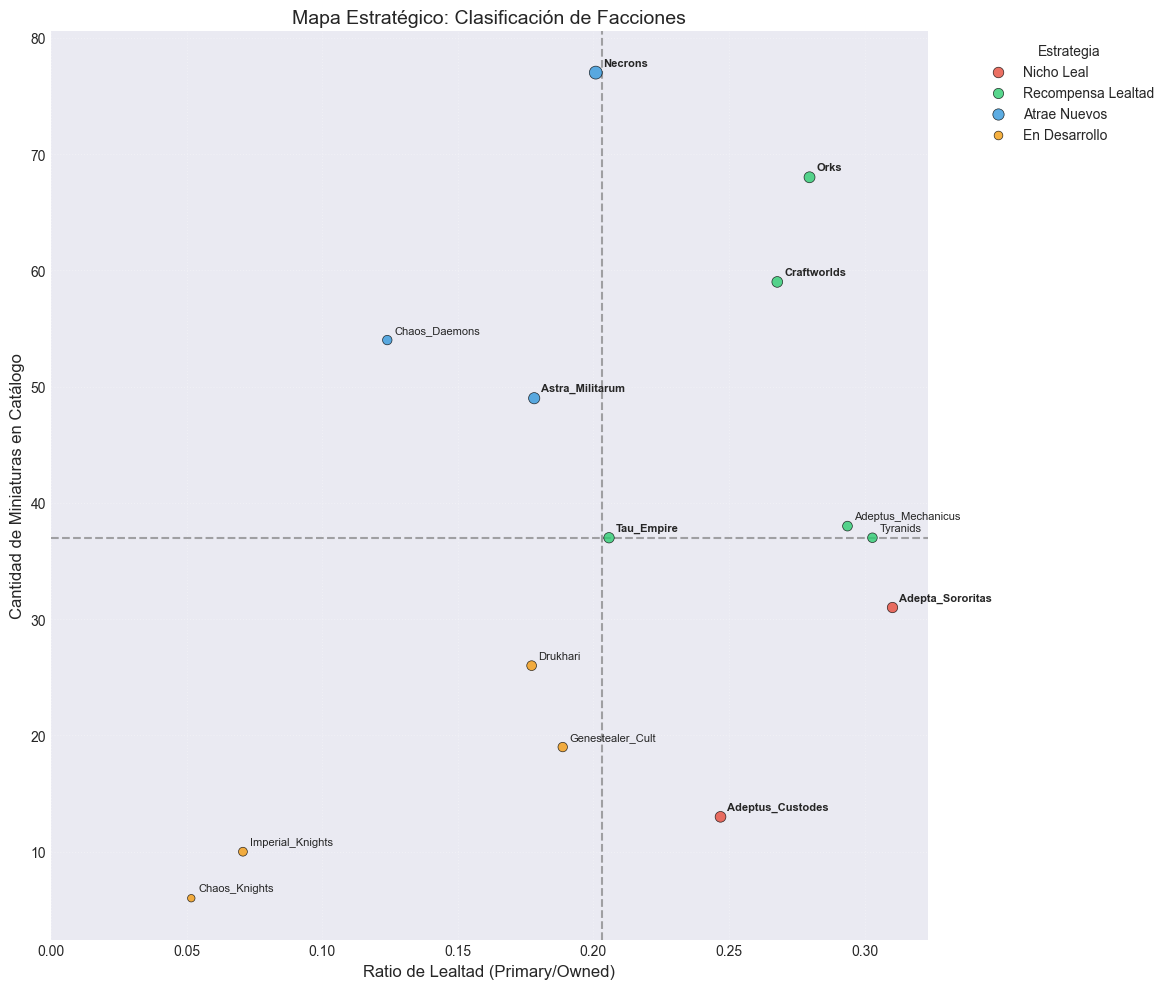

In [434]:
color_map = {
    'Recompensa Lealtad': '#2ecc71',  # Verde
    'Atrae Nuevos': '#3498db',        # Azul
    'Nicho Leal': '#e74c3c',          # Rojo
    'En Desarrollo': '#f39c12'        # Naranja
}

plt.figure(figsize=(14, 10))

for strategy in loyalty_support_merge['strategy_type'].unique():
    subset = loyalty_support_merge[loyalty_support_merge['strategy_type'] == strategy]
    color = color_map.get(strategy, '#95a5a6') 
    
    plt.scatter(
        subset['loyalty_ratio'],
        subset['mini_count'],
        s=subset['Owned'] / 8,
        c=color,
        label=strategy, 
        alpha=0.8, 
        edgecolors='black',
        linewidth=0.5,
        zorder=5
    )

# Líneas de Cuadrantes (usando las medianas calculadas)
plt.axvline(x=med_loyalty, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=med_minis, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Anotaciones de Facciones
for _, row in loyalty_support_merge.iterrows():
    plt.annotate(
        row['faction_clean'], 
        (row['loyalty_ratio'], row['mini_count']), 
        fontsize=8, 
        xytext=(5, 5), 
        textcoords='offset points',
        fontweight='bold' if row['Owned'] > loyalty_support_merge['Owned'].median() else 'normal'
    )

plt.xlabel('Ratio de Lealtad (Primary/Owned)', fontsize=12)
plt.ylabel('Cantidad de Miniaturas en Catálogo', fontsize=12)
plt.title('Mapa Estratégico: Clasificación de Facciones', fontsize=14)
plt.legend(title="Estrategia", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3, linestyle=':')
plt.xlim(left=0)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig('../img/hipotesis_10_strategy_map_dynamic.png', dpi=300, bbox_inches='tight')
plt.show()

In [435]:
# 10.7 - Función utilitaria: Analizar estrategia de facción
def analyze_faction_strategy(faction_name):
    """Analiza la estrategia de soporte para una facción específica"""
    faction_data = loyalty_support_merge[loyalty_support_merge['faction_clean'] == faction_name]
    if faction_data.empty:
        return f"❌ Facción '{faction_name}' no encontrada"
    
    row = faction_data.iloc[0]
    
    # Calcular percentiles para contexto
    loyalty_pct = (loyalty_support_merge['loyalty_ratio'] < row['loyalty_ratio']).mean() * 100
    support_pct = (loyalty_support_merge['mini_count'] < row['mini_count']).mean() * 100
    
    return f"""
🎯 Análisis Estratégico: {faction_name}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): {row['loyalty_ratio']:.2%} (Percentil: {loyalty_pct:.0f}%)
🎲 Soporte (Miniaturas): {row['mini_count']:.0f} (Percentil: {support_pct:.0f}%)
📚 Ediciones Soportadas: {row['editions_supported']:.0f}
🏆 Real Win Rate: {row['Real Win %']:.1f}%
🎮 Popularidad (Owned): {row['Owned']:.0f}

📋 Estrategia Identificada: {row['strategy_type']}

💡 Recomendación:
{
    '✅ Mantener inversión: facción leal y bien soportada' if row['strategy_type'] == 'Recompensa Lealtad' else
    '🎯 Oportunidad de crecimiento: alta lealtad, bajo soporte' if row['strategy_type'] == 'Nicho Leal' else
    '📈 Estrategia de expansión: bajo ratio de lealtad, alto soporte' if row['strategy_type'] == 'Atrae Nuevos' else
    '🔍 Monitorear: facción en fase de desarrollo'
}
"""


In [436]:
# Ejemplos de uso
print("\n EJEMPLOS DE ANÁLISIS ESTRATÉGICO:")
print(analyze_faction_strategy("Necrons"))
print(analyze_faction_strategy("Adepta_Sororitas"))


 EJEMPLOS DE ANÁLISIS ESTRATÉGICO:

🎯 Análisis Estratégico: Necrons
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): 20.09% (Percentil: 43%)
🎲 Soporte (Miniaturas): 77 (Percentil: 93%)
📚 Ediciones Soportadas: 8
🏆 Real Win Rate: 51.0%
🎮 Popularidad (Owned): 692

📋 Estrategia Identificada: Atrae Nuevos

💡 Recomendación:
📈 Estrategia de expansión: bajo ratio de lealtad, alto soporte


🎯 Análisis Estratégico: Adepta_Sororitas
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
👥 Lealtad (Primary/Owned): 31.03% (Percentil: 93%)
🎲 Soporte (Miniaturas): 31 (Percentil: 36%)
📚 Ediciones Soportadas: 6
🏆 Real Win Rate: 50.0%
🎮 Popularidad (Owned): 448

📋 Estrategia Identificada: Nicho Leal

💡 Recomendación:
🎯 Oportunidad de crecimiento: alta lealtad, bajo soporte

